<a href="https://colab.research.google.com/github/YashviGupta15/ai-ml-notes/blob/main/Hugging_Face_Pipeline_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture: Transformer Encoder Block — From Multi-Head Attention to BERT-Style Encoders

## Today's Lecture Flow

In the previous lecture, we completed the core mathematics and implementation intuition of:

- Query, Key, Value
- Scaled Dot-Product Attention
- Multi-Head Attention
- Shape flow inside attention

Today, we move one level higher.

Instead of asking:

> How does attention work?

we now ask:

> How is attention used inside a full Transformer Encoder Block?

A Transformer Encoder Block is not just Multi-Head Attention.

It contains:

1. Multi-Head Self-Attention
2. Residual Connection
3. Layer Normalization
4. Feed-Forward Network
5. Second Residual Connection
6. Second Layer Normalization

This block is repeated multiple times to build models like BERT.

## 1. From MHA Output to Transformer Encoder Block

### Core Idea

Multi-Head Attention gives each token a context-aware representation.

But the Transformer Encoder does not directly stop at MHA.

The raw MHA output still needs:

- stability during training,
- better gradient flow,
- token-wise nonlinear transformation,
- repeated refinement through stacked layers.

So the encoder block wraps MHA with additional mechanisms.

The high-level structure is:

$$
X \rightarrow \text{Multi-Head Attention} \rightarrow \text{Add \& Norm} \rightarrow \text{Feed-Forward Network} \rightarrow \text{Add \& Norm}
$$

Here:

- $X$ is the input embedding sequence,
- MHA mixes information across tokens,
- FFN transforms each token independently,
- residual connections protect the original information,
- layer normalization stabilizes the representation.

## 1.1 Shape View of Encoder Input and MHA Output

Let the input to the encoder block be:

$$
X \in \mathbb{R}^{B \times T \times d_{\text{model}}}
$$

where:

- $B$ = batch size
- $T$ = sequence length
- $d_{\text{model}}$ = embedding dimension

After Multi-Head Attention:

$$
\text{MHA}(X) \in \mathbb{R}^{B \times T \times d_{\text{model}}}
$$

This shape preservation is very important.

Because the input and MHA output have the same shape, we can add them directly using a residual connection.

$$
X + \text{MHA}(X)
$$

In [ ]:
# Code Cell: Setup

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)

B = 2       # batch size
T = 5       # sequence length
d_model = 8 # embedding dimension

X = torch.randn(B, T, d_model)

print("Input X shape:", X.shape)

Input X shape: torch.Size([2, 5, 8])


### Observation

The input tensor represents a batch of token embeddings.

For example:

- batch size = 2 means two sentences,
- sequence length = 5 means each sentence has five tokens,
- embedding dimension = 8 means every token is represented by an 8-dimensional vector.

In real Transformer models, $d_{\text{model}}$ is usually much larger, such as 768 in BERT-base.

## 1.2 A Minimal Multi-Head Attention Module

Before building the encoder block, we first define a reusable Multi-Head Self-Attention module.

Since the detailed mathematics of attention has already been covered, here we focus on implementation and shape movement.

In [ ]:
# Code Cell: Multi-Head Self-Attention From Scratch

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, d_model = x.shape

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # Split into multiple heads
        Q = Q.view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.d_head).transpose(1, 2)

        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_head ** 0.5)
        attention_weights = F.softmax(scores, dim=-1)

        # Weighted sum of values
        context = torch.matmul(attention_weights, V)

        # Merge heads
        context = context.transpose(1, 2).contiguous().view(B, T, d_model)

        # Final output projection
        out = self.W_o(context)

        return out, attention_weights

In [ ]:
# Code Cell: Testing MHA Output Shape

num_heads = 2

mha = MultiHeadSelfAttention(d_model=d_model, num_heads=num_heads)

mha_output, attention_weights = mha(X)

print("Input X shape:       ", X.shape)
print("MHA output shape:    ", mha_output.shape)
print("Attention shape:     ", attention_weights.shape)

Input X shape:        torch.Size([2, 5, 8])
MHA output shape:     torch.Size([2, 5, 8])
Attention shape:      torch.Size([2, 2, 5, 5])


### Observation

The Multi-Head Attention output has the same shape as the input:

$$
X \in \mathbb{R}^{B \times T \times d_{\text{model}}}
$$

$$
\text{MHA}(X) \in \mathbb{R}^{B \times T \times d_{\text{model}}}
$$

This is not accidental.

This shape matching allows the next important operation:

$$
X + \text{MHA}(X)
$$

This is the residual connection.

## 1.3 Why MHA Alone Is Not Enough

Multi-Head Attention is powerful because each token can collect information from other tokens.

But MHA alone has some limitations:

1. It may disturb useful original token information.
2. Deep models become difficult to train without skip paths.
3. The output distribution can shift across layers.
4. MHA mainly mixes token-level information, but we also need token-wise nonlinear transformation.

Therefore, the Transformer Encoder Block adds:

- residual connection,
- layer normalization,
- feed-forward network.

The MHA is only the first major component inside the encoder block.

## 1.4 Practical View: MHA as a Representation Refiner

Think of the input $X$ as the initial understanding of tokens.

After MHA:

- each token has looked at other tokens,
- each token representation becomes context-aware,
- word meaning becomes sentence-dependent.

For example, in the sentence:

> The bank approved the loan.

The token "bank" should attend more to "loan".

But in:

> The bank of the river was muddy.

The token "bank" should attend more to "river".

MHA helps create these context-aware token vectors.

In [ ]:
# Code Cell: Compare Input Token Vector and MHA Output Token Vector

sentence_id = 0
token_id = 2

print("Original token vector:")
print(X[sentence_id, token_id])

print("\nContext-aware token vector after MHA:")
print(mha_output[sentence_id, token_id])

Original token vector:
tensor([ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806])

Context-aware token vector after MHA:
tensor([-0.2076, -0.3059, -0.5706, -0.0585,  0.1355,  0.1923, -0.1840, -0.2565],
       grad_fn=<SelectBackward0>)


### Observation

The original token vector and the MHA output vector are different.

The MHA output is not simply the same embedding.

It is a transformed representation that depends on:

- the token itself,
- other tokens in the sequence,
- attention weights,
- learned projection matrices.

This context-aware representation is passed to the next stage of the encoder block.

## 1.5 Visualizing Attention Weights for One Head

The attention matrix tells us how much each token attends to every other token.

For each attention head, the shape is:

$$
T \times T
$$

For a batch and multiple heads, the full shape is:

$$
B \times h \times T \times T
$$

where $h$ is the number of heads.

In [ ]:
# Code Cell: Print Attention Matrix for One Sentence and One Head

sentence_id = 0
head_id = 0

attn_matrix = attention_weights[sentence_id, head_id]

print("Attention matrix shape:", attn_matrix.shape)
print(attn_matrix)

Attention matrix shape: torch.Size([5, 5])
tensor([[0.3273, 0.1665, 0.1598, 0.1471, 0.1993],
        [0.1950, 0.2531, 0.1916, 0.2099, 0.1505],
        [0.1264, 0.2445, 0.1446, 0.1864, 0.2981],
        [0.0870, 0.1950, 0.2457, 0.2737, 0.1987],
        [0.2569, 0.2105, 0.1847, 0.1779, 0.1700]], grad_fn=<SelectBackward0>)


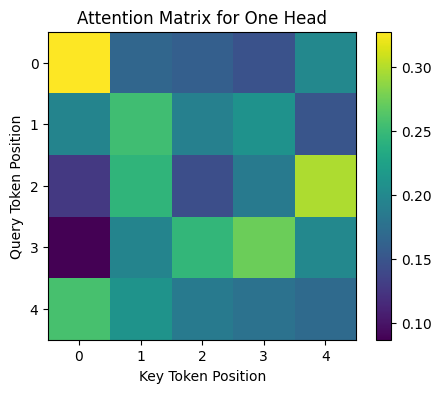

In [ ]:
# Code Cell: Visualize Attention Matrix

import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.imshow(attn_matrix.detach().numpy())
plt.colorbar()
plt.title("Attention Matrix for One Head")
plt.xlabel("Key Token Position")
plt.ylabel("Query Token Position")
plt.show()

### Observation

Each row of the attention matrix represents one query token.

Each column represents a key token.

A row tells us:

> For this token, how much attention is assigned to all tokens in the sequence?

Because softmax is applied row-wise, each row sums approximately to 1.

In [ ]:
# Code Cell: Verify Row-Wise Sum of Attention Weights

row_sums = attn_matrix.sum(dim=-1)

print("Row sums:")
print(row_sums)

Row sums:
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)


## 1.6 Encoder Block Skeleton

At this point, we can define the skeleton of a Transformer Encoder Block.

We are not implementing the full block yet.

We first observe the structure:

```python
x = input

attention_output = MultiHeadAttention(x)

x = AddNorm(x, attention_output)

ffn_output = FeedForward(x)

x = AddNorm(x, ffn_output)

In [ ]:
# Code Cell: Encoder Block Skeleton Without Full Details

class EncoderBlockSkeleton(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.mha = MultiHeadSelfAttention(d_model, num_heads)

    def forward(self, x):
        attention_output, attention_weights = self.mha(x)

        # Later we will add:
        # x = LayerNorm(x + attention_output)
        # ffn_output = FeedForward(x)
        # x = LayerNorm(x + ffn_output)

        return attention_output, attention_weights

In [ ]:
# Code Cell: Testing Encoder Skeleton

encoder_skeleton = EncoderBlockSkeleton(d_model=d_model, num_heads=num_heads)

attention_output, attention_weights = encoder_skeleton(X)

print("Input shape:             ", X.shape)
print("Attention output shape:  ", attention_output.shape)
print("Attention weights shape: ", attention_weights.shape)

Input shape:              torch.Size([2, 5, 8])
Attention output shape:   torch.Size([2, 5, 8])
Attention weights shape:  torch.Size([2, 2, 5, 5])


### Observation

The encoder block begins with Multi-Head Self-Attention.

But this output is not yet the final encoder block output.

The next immediate step is:

$$
X + \text{MHA}(X)
$$

This is called the residual connection after Multi-Head Attention.

We will study this next.

## Concept Check Questions: From MHA Output to Encoder Block

### Q1. Regular Question

Why should the output of Multi-Head Attention have the same shape as the input $X$?

---

### Q2. MCQ

Suppose the input to a Transformer Encoder block has shape:

$$
(32, 20, 128)
$$

where:

- batch size = 32
- sequence length = 20
- embedding dimension = 128

What should be the shape of the Multi-Head Attention output?

A. $(32, 128, 20)$  
B. $(32, 20, 128)$  
C. $(20, 32, 128)$  
D. $(32, 20, 20)$

---

### Q3. Practical Debugging Question

A student writes the following code:

```python
x = torch.randn(4, 10, 64)
attention_output = torch.randn(4, 10, 32)

result = x + attention_output

## Q4. Higher-Quality Interview-Type Question

Multi-Head Attention already creates context-aware token representations.

Then why do we still need the rest of the Transformer Encoder Block?

### Answer 4
Multi-Head Attention mixes information across tokens, but it does not complete the full transformation needed by the encoder.

The encoder block also needs:

Residual connections to preserve original information and improve gradient flow.
Layer normalization to stabilize training.
Feed-forward networks to apply nonlinear token-wise transformation.
Stacking of multiple blocks to progressively refine representations.

So MHA is the core contextualization mechanism, but the full encoder block makes the architecture trainable, stable, and expressive.

## Bridge to Next Topic

We now understand that Multi-Head Attention produces a context-aware tensor with the same shape as the input.

The next question is:

> Why does the Transformer add the original input back to the MHA output?

This takes us to the next topic:

   ##### Residual Connection After Multi-Head Attention #####

## 2. Residual Connection After Multi-Head Attention

### Core Idea

After Multi-Head Attention, each token has collected contextual information from other tokens.

But instead of directly passing the MHA output forward, the Transformer adds the original input back:

$$
Z = X + \text{MHA}(X)
$$

This is called a residual connection or skip connection.

The purpose is simple:

> Do not force the model to completely replace the original token representation.  
> Let it learn and update on top of the original representation.

So the MHA block learns a correction or refinement, not an entirely new representation from scratch.

## 2.1 Why Residual Connection Is Needed

Deep neural networks can become difficult to train because gradients may become weak as they pass through many layers.

Residual connections help by creating a direct path for information and gradients.

Without residual connection:

$$
X \rightarrow \text{MHA}(X)
$$

With residual connection:

$$
X \rightarrow X + \text{MHA}(X)
$$

This means the model can preserve the original input while adding contextual information learned by attention.

In practical terms:

- $X$ carries the original token representation.
- $\text{MHA}(X)$ carries contextual information.
- $X + \text{MHA}(X)$ combines both.

In [ ]:
# Code Cell: Setup for Residual Connection

# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# torch.manual_seed(42)

# B = 2
# T = 5
# d_model = 8
# num_heads = 2

# X = torch.randn(B, T, d_model)

# print("Input X shape:", X.shape)


In [ ]:
# # Code Cell: Reusable Multi-Head Self-Attention Module

# class MultiHeadSelfAttention(nn.Module):
#     def __init__(self, d_model, num_heads):
#         super().__init__()

#         assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

#         self.d_model = d_model
#         self.num_heads = num_heads
#         self.d_head = d_model // num_heads

#         self.W_q = nn.Linear(d_model, d_model)
#         self.W_k = nn.Linear(d_model, d_model)
#         self.W_v = nn.Linear(d_model, d_model)
#         self.W_o = nn.Linear(d_model, d_model)

#     def forward(self, x):
#         B, T, d_model = x.shape

#         Q = self.W_q(x)
#         K = self.W_k(x)
#         V = self.W_v(x)

#         Q = Q.view(B, T, self.num_heads, self.d_head).transpose(1, 2)
#         K = K.view(B, T, self.num_heads, self.d_head).transpose(1, 2)
#         V = V.view(B, T, self.num_heads, self.d_head).transpose(1, 2)

#         scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_head ** 0.5)
#         attention_weights = F.softmax(scores, dim=-1)

#         context = torch.matmul(attention_weights, V)

#         context = context.transpose(1, 2).contiguous().view(B, T, d_model)

#         out = self.W_o(context)

#         return out, attention_weights

## 2.2 Applying Residual Connection

Since both tensors have the same shape:

$$
X \in \mathbb{R}^{B \times T \times d_{\text{model}}}
$$

and

$$
\text{MHA}(X) \in \mathbb{R}^{B \times T \times d_{\text{model}}}
$$

we can add them directly:

$$
Z = X + \text{MHA}(X)
$$

Here $Z$ is not yet the final output of the first sub-layer.

After this, Layer Normalization will be applied.

In [ ]:
# Code Cell: Residual Connection After MHA

residual_output = X + mha_output

print("Input X shape:          ", X.shape)
print("MHA output shape:       ", mha_output.shape)
print("Residual output shape:  ", residual_output.shape)

Input X shape:           torch.Size([2, 5, 8])
MHA output shape:        torch.Size([2, 5, 8])
Residual output shape:   torch.Size([2, 5, 8])


### Observation

The residual output has the same shape as the input:

$$
B \times T \times d_{\text{model}}
$$

This is important because the Transformer Encoder block repeatedly preserves this shape across layers.

The sequence length remains the same.

The embedding dimension remains the same.

Only the quality of the token representation changes.

## 2.3 Token-Level View of Residual Addition

For a single token position $t$, residual addition can be understood as:

$$
z_t = x_t + \text{mha}_t
$$

where:

- $x_t$ is the original token vector,
- $\text{mha}_t$ is the context-aware update from attention,
- $z_t$ is the combined representation.

So each token receives an update, but its original identity is not erased.

In [ ]:
# Code Cell: Inspect One Token Before and After Residual Addition

sentence_id = 0
token_id = 2

print("Original token vector X:")
print(X[sentence_id, token_id])

print("\nMHA output vector:")
print(mha_output[sentence_id, token_id])

print("\nAfter residual addition X + MHA(X):")
print(residual_output[sentence_id, token_id])

Original token vector X:
tensor([ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806])

MHA output vector:
tensor([-0.2076, -0.3059, -0.5706, -0.0585,  0.1355,  0.1923, -0.1840, -0.2565],
       grad_fn=<SelectBackward0>)

After residual addition X + MHA(X):
tensor([ 1.4347, -0.4655, -1.0680,  0.3811, -0.6226,  1.2706,  0.6168,  1.4241],
       grad_fn=<SelectBackward0>)


### Observation

The residual output is obtained by element-wise addition.

For every token vector:

```python
residual_output = original_vector + attention_update


## 2.4 Practical Intuition: MHA Learns an Update

A useful way to understand residual connection is:

$$
\text{new representation} = \text{old representation} + \text{learned update}
$$

In the Transformer Encoder:

$$
Z = X + \text{MHA}(X)
$$

This means:

- if attention finds useful context, it can add meaningful information,
- if attention is not useful at some stage, the model can still preserve the original input,
- deep stacking becomes easier because information has a direct route across layers.

This is one reason why very deep Transformer models can be trained effectively.

In [ ]:
# Code Cell: Check Magnitudes Before and After Residual Addition

x_norm = X.norm(dim=-1)
mha_norm = mha_output.norm(dim=-1)
residual_norm = residual_output.norm(dim=-1)

print("Norm of original token vectors:")
print(x_norm)

print("\nNorm of MHA output token vectors:")
print(mha_norm)

print("\nNorm after residual addition:")
print(residual_norm)

Norm of original token vectors:
tensor([[3.9662, 2.7246, 2.8925, 2.5158, 2.5789],
        [3.5277, 2.1006, 3.0266, 3.3045, 2.5813]])

Norm of MHA output token vectors:
tensor([[0.7263, 0.7859, 0.7879, 0.8094, 0.8011],
        [1.2644, 1.2359, 1.3213, 1.2648, 1.2360]],
       grad_fn=<LinalgVectorNormBackward0>)

Norm after residual addition:
tensor([[4.0529, 2.7780, 2.8234, 2.0777, 3.0213],
        [4.0491, 2.6596, 3.5203, 2.5186, 2.9059]],
       grad_fn=<LinalgVectorNormBackward0>)


### Observation

The norm gives a rough idea of vector magnitude.

After residual addition, the vector magnitude may change.

This is one reason why Layer Normalization is applied immediately after residual addition.

Without normalization, repeated residual additions across many layers may make representations unstable.

## 2.5 What Can Go Wrong Without Shape Matching?

Residual addition requires identical tensor shapes.

This is valid:

```python
X.shape = (B, T, d_model)
mha_output.shape = (B, T, d_model)

```python
X.shape = (B, T, d_model)
mha_output.shape = (B, T, d_hidden)

In [ ]:

# Code Cell: Demonstrating Shape Error in Residual Addition

x = torch.randn(4, 10, 64)
wrong_attention_output = torch.randn(4, 10, 32)

try:
    result = x + wrong_attention_output
except RuntimeError as e:
    print("Error during residual addition:")
    print(e)

Error during residual addition:
The size of tensor a (64) must match the size of tensor b (32) at non-singleton dimension 2


### Observation

Residual addition is not concatenation.

It is element-wise addition.

Therefore, the model dimensions must match exactly.

This is why Transformer components are carefully designed to preserve:

$$
B \times T \times d_{\text{model}}
$$

across the encoder block.

## 2.6 Residual Connection as a Small PyTorch Module

For clean implementation, we can create a small residual wrapper.

This wrapper simply adds the original input to the sub-layer output.

Later, we will combine this with Layer Normalization.

In [ ]:
# Code Cell: Residual Connection Module

class ResidualConnection(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x, sublayer_output):
        return x + sublayer_output

In [ ]:
# Code Cell: Test ResidualConnection Module

residual = ResidualConnection()

z = residual(X, mha_output)

print("X shape:              ", X.shape)
print("MHA output shape:     ", mha_output.shape)
print("Residual output shape:", z.shape)

print("\nCheck equality with direct addition:")
print(torch.allclose(z, X + mha_output))

X shape:               torch.Size([2, 5, 8])
MHA output shape:      torch.Size([2, 5, 8])
Residual output shape: torch.Size([2, 5, 8])

Check equality with direct addition:
True


### Observation

The custom residual module gives the same result as direct addition.

This may look simple, but conceptually it is one of the most important design decisions in the Transformer.

Residual connections allow information to survive across many layers.

In [ ]:

# Code Cell: Encoder Skeleton With Residual Connection

class EncoderBlockWithResidual(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.mha = MultiHeadSelfAttention(d_model, num_heads)
        self.residual = ResidualConnection()

    def forward(self, x):
        attention_output, attention_weights = self.mha(x)
        x = self.residual(x, attention_output)
        return x, attention_weights

In [ ]:
# Code Cell: Test Encoder Skeleton With Residual Connection

encoder_residual = EncoderBlockWithResidual(d_model=d_model, num_heads=num_heads)

out, attention_weights = encoder_residual(X)

print("Input shape:  ", X.shape)
print("Output shape: ", out.shape)

Input shape:   torch.Size([2, 5, 8])
Output shape:  torch.Size([2, 5, 8])


### Observation

The output shape remains unchanged:

$$
B \times T \times d_{\text{model}}
$$

This shape consistency allows us to keep adding components without breaking the architecture.

Next, we will stabilize this residual output using Layer Normalization.

## Concept Check Questions: Residual Connection After MHA

### Q1. Regular Question

Why does the Transformer add the original input $X$ to the output of Multi-Head Attention?

---

### Q2. MCQ

Which operation correctly represents the residual connection after Multi-Head Attention?

A. $\text{Concat}(X, \text{MHA}(X))$  
B. $X + \text{MHA}(X)$  
C. $X \times \text{MHA}(X)$  
D. $\text{MHA}(X) - X$

---

### Q3. Shape-Based Question

Suppose:

```python
X.shape = (16, 12, 256)
mha_output.shape = (16, 12, 256)
What will be the output of:
Z = X + mha_output

### Q4. Interview-Type Question

Why are residual connections especially important when Transformer Encoder blocks are stacked many times?

### Answer 4

Residual connections are important in stacked Transformer Encoder blocks because they provide a direct path for information and gradients.

Without residual connections, deep stacks can become difficult to optimize because each layer must completely transform the representation.

With residual connections, each layer only needs to learn a useful refinement on top of the previous representation.

This makes deep Transformer models more stable and trainable.


## Bridge to Next Topic

We have now applied the first residual connection:

$$
Z = X + \text{MHA}(X)
$$

But repeated additions can change the scale and distribution of token vectors.

So before passing this representation forward, the Transformer stabilizes it using Layer Normalization.

Next topic:

#### Layer Normalization From Scratch

## 3. Layer Normalization From Scratch

### Core Idea

After residual addition, the representation becomes:

$$
Z = X + \text{MHA}(X)
$$

But this addition can change the scale of token vectors.

If we keep stacking layers, these scale changes may accumulate and make training unstable.

Layer Normalization solves this by normalizing each token vector across its feature dimension.

For an input tensor:

$$
Z \in \mathbb{R}^{B \times T \times d_{\text{model}}}
$$

Layer Normalization normalizes each token vector of size:

$$
d_{\text{model}}
$$

independently.

## 3.1 What Exactly Does LayerNorm Normalize?

Suppose one token vector is:

$$
z_t \in \mathbb{R}^{d_{\text{model}}}
$$

LayerNorm computes the mean and variance across the feature dimension of this single token vector.

So for every token independently:

$$
\mu_t = \frac{1}{d_{\text{model}}} \sum_{i=1}^{d_{\text{model}}} z_{t,i}
$$

$$
\sigma_t^2 = \frac{1}{d_{\text{model}}} \sum_{i=1}^{d_{\text{model}}} (z_{t,i} - \mu_t)^2
$$

Then:

$$
\hat{z}_{t,i} = \frac{z_{t,i} - \mu_t}{\sqrt{\sigma_t^2 + \epsilon}}
$$

Here, $\epsilon$ is a small value added for numerical stability.

LayerNorm does not normalize across the batch.

It normalizes across features for each token independently.

In [ ]:
# Code Cell: Setup for LayerNorm

import torch
import torch.nn as nn

torch.manual_seed(42)

B = 2
T = 5
d_model = 8

Z = torch.randn(B, T, d_model)

print("Input Z shape:", Z.shape)

Input Z shape: torch.Size([2, 5, 8])


## 3.2 Inspecting One Token Vector

To understand LayerNorm clearly, we first inspect one token vector.

For one token:

$$
z_t \in \mathbb{R}^{8}
$$

In this toy example, $d_{\text{model}} = 8$.

LayerNorm will compute the mean and variance across these 8 values.

In [ ]:
# Code Cell: Select One Token Vector

sentence_id = 0
token_id = 2

token_vector = Z[sentence_id, token_id]

print("Token vector shape:", token_vector.shape)
print(token_vector)

Token vector shape: torch.Size([8])
tensor([ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806])


In [ ]:
# Code Cell: Mean and Variance of One Token Vector

mean = token_vector.mean()
variance = token_vector.var(unbiased=False)

print("Mean:", mean.item())
print("Variance:", variance.item())

Mean: 0.5283148288726807
Variance: 0.7667106986045837


### Observation

For this selected token, LayerNorm computes one mean and one variance.

These values are computed only across the embedding dimension.

So if the token vector has 8 features, the mean and variance are calculated using those 8 values.

This is done separately for every token in every sentence.

## 3.3 Manual Layer Normalization for One Token

Now we manually normalize the selected token vector.

The normalized vector should have approximately:

- mean close to 0,
- variance close to 1.

This is the core behavior of normalization.

In [ ]:
# Code Cell: Manual LayerNorm for One Token

eps = 1e-5

token_norm = (token_vector - mean) / torch.sqrt(variance + eps)

print("Normalized token vector:")
print(token_norm)

print("\nMean after normalization:", token_norm.mean().item())
print("Variance after normalization:", token_norm.var(unbiased=False).item())

Normalized token vector:
tensor([ 1.2722, -0.7856, -1.1714, -0.1013, -1.4692,  0.6281,  0.3112,  1.3160])

Mean after normalization: 1.4901161193847656e-08
Variance after normalization: 0.9999868869781494


### Observation

After normalization, the token vector is centered and scaled.

Its mean becomes close to 0.

Its variance becomes close to 1.

Because of $\epsilon$, the variance may not be exactly 1, but it should be very close.

## 3.4 Manual LayerNorm for the Full Tensor

Now we apply the same idea to the full tensor:

$$
Z \in \mathbb{R}^{B \times T \times d_{\text{model}}}
$$

For LayerNorm, we compute mean and variance along the last dimension:

```python
dim=-1

In [ ]:
# Code Cell: Manual LayerNorm for Full Tensor

mean = Z.mean(dim=-1, keepdim=True)
variance = Z.var(dim=-1, keepdim=True, unbiased=False)

Z_norm = (Z - mean) / torch.sqrt(variance + eps)

print("Original Z shape:", Z.shape)
print("Mean shape:      ", mean.shape)
print("Variance shape:  ", variance.shape)
print("Z_norm shape:    ", Z_norm.shape)

Original Z shape: torch.Size([2, 5, 8])
Mean shape:       torch.Size([2, 5, 1])
Variance shape:   torch.Size([2, 5, 1])
Z_norm shape:     torch.Size([2, 5, 8])


### Observation

The mean shape is:

$$
B \times T \times 1
$$

The variance shape is also:

$$
B \times T \times 1
$$

This means every token gets its own mean and variance.

The final normalized output keeps the same shape:

$$
B \times T \times d_{\text{model}}
$$

In [ ]:
# Code Cell: Verify Mean and Variance After Full Tensor Normalization

mean_after = Z_norm.mean(dim=-1)
var_after = Z_norm.var(dim=-1, unbiased=False)

print("Mean after normalization for every token:")
print(mean_after)

print("\nVariance after normalization for every token:")
print(var_after)

Mean after normalization for every token:
tensor([[-1.4901e-08,  1.4901e-08,  1.4901e-08,  3.7253e-08,  2.9802e-08],
        [ 2.0489e-08,  7.4506e-09, -1.4901e-08,  1.4901e-08,  0.0000e+00]])

Variance after normalization for every token:
tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]])


### Observation

Each token vector now has mean close to 0 and variance close to 1.

This confirms that LayerNorm is applied independently per token.

The batch dimension is not used to compute normalization statistics.

## 3.5 Why LayerNorm Is Better Than BatchNorm for Transformers

Batch Normalization computes statistics across the batch dimension.

That is useful in CNNs, where batch-level statistics are often stable.

But in NLP and sequence modeling:

- sequence lengths may vary,
- batch sizes may be small,
- token positions have different meanings,
- autoregressive generation may process one example at a time.

LayerNorm avoids these issues because it normalizes each token independently.

It does not depend on other samples in the batch.

## 3.6 Adding Learnable Scale and Shift

LayerNorm does not only normalize.

It also learns two parameters:

$$
\gamma
$$

and

$$
\beta
$$

The final output is:

$$
\text{LayerNorm}(z) = \gamma \hat{z} + \beta
$$

where:

- $\gamma$ is the learnable scale,
- $\beta$ is the learnable shift.

Both have shape:

$$
d_{\text{model}}
$$

This allows the model to decide how much normalized information should be scaled or shifted.

In [ ]:
# Code Cell: LayerNorm With Learnable Gamma and Beta

gamma = nn.Parameter(torch.ones(d_model))
beta = nn.Parameter(torch.zeros(d_model))

Z_layernorm_manual = gamma * Z_norm + beta

print("Gamma shape:", gamma.shape)
print("Beta shape: ", beta.shape)
print("Manual LayerNorm output shape:", Z_layernorm_manual.shape)

Gamma shape: torch.Size([8])
Beta shape:  torch.Size([8])
Manual LayerNorm output shape: torch.Size([2, 5, 8])


### Observation

The learnable parameters $\gamma$ and $\beta$ have shape:

$$
d_{\text{model}}
$$

They are broadcast across:

- batch dimension,
- sequence dimension.

So every token uses the same scale and shift parameters for each feature.

## 3.7 Creating LayerNorm From Scratch as a PyTorch Module

Now we implement Layer Normalization from scratch.

This module will:

1. compute mean across the last dimension,
2. compute variance across the last dimension,
3. normalize,
4. apply learnable scale and shift.

In [ ]:
# Code Cell: LayerNorm From Scratch

class LayerNormFromScratch(nn.Module):
    def __init__(self, d_model, eps=1e-5):
        super().__init__()

        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        variance = x.var(dim=-1, keepdim=True, unbiased=False)

        x_norm = (x - mean) / torch.sqrt(variance + self.eps)

        return self.gamma * x_norm + self.beta

In [ ]:
# Code Cell: Test Custom LayerNorm

custom_ln = LayerNormFromScratch(d_model=d_model)

Z_custom_norm = custom_ln(Z)

print("Input shape:              ", Z.shape)
print("Custom LayerNorm shape:   ", Z_custom_norm.shape)

Input shape:               torch.Size([2, 5, 8])
Custom LayerNorm shape:    torch.Size([2, 5, 8])


In [ ]:
# Code Cell: Verify Custom LayerNorm Output Statistics

custom_mean_after = Z_custom_norm.mean(dim=-1)
custom_var_after = Z_custom_norm.var(dim=-1, unbiased=False)

print("Mean after custom LayerNorm:")
print(custom_mean_after)

print("\nVariance after custom LayerNorm:")
print(custom_var_after)

Mean after custom LayerNorm:
tensor([[-1.4901e-08,  1.4901e-08,  1.4901e-08,  3.7253e-08,  2.9802e-08],
        [ 2.0489e-08,  7.4506e-09, -1.4901e-08,  1.4901e-08,  0.0000e+00]],
       grad_fn=<MeanBackward1>)

Variance after custom LayerNorm:
tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]], grad_fn=<VarBackward0>)


### Observation

The custom LayerNorm module behaves as expected.

Each token vector is normalized across the feature dimension.

Since $\gamma = 1$ and $\beta = 0$ initially, the output still has approximately:

- mean 0,
- variance 1.

During training, $\gamma$ and $\beta$ will be learned.

## 3.8 Comparing Custom LayerNorm With PyTorch LayerNorm

PyTorch already provides:

```python
nn.LayerNorm(d_model)

In [ ]:
# Code Cell: Compare Custom LayerNorm With nn.LayerNorm

torch_ln = nn.LayerNorm(d_model, eps=1e-5)

# Copy same gamma and beta values from custom layernorm
with torch.no_grad():
    torch_ln.weight.copy_(custom_ln.gamma)
    torch_ln.bias.copy_(custom_ln.beta)

Z_torch_norm = torch_ln(Z)

print("Custom LayerNorm output shape:", Z_custom_norm.shape)
print("PyTorch LayerNorm output shape:", Z_torch_norm.shape)

print("\nAre outputs close?")
print(torch.allclose(Z_custom_norm, Z_torch_norm, atol=1e-6))

Custom LayerNorm output shape: torch.Size([2, 5, 8])
PyTorch LayerNorm output shape: torch.Size([2, 5, 8])

Are outputs close?
True


### Observation

Our implementation matches PyTorch's `nn.LayerNorm`.

This confirms that LayerNorm is conceptually simple:

```python
normalize across the last dimension
then apply learnable scale and shift

## 3.9 LayerNorm After Residual Addition

In the Transformer Encoder block, LayerNorm is applied after residual addition in the original Transformer design.

The operation becomes:

$$
\text{LayerNorm}(X + \text{MHA}(X))
$$

This is called:

$$
\text{Add \& Norm}
$$

The "Add" refers to residual addition.

The "Norm" refers to Layer Normalization.

In [ ]:
# Code Cell: LayerNorm After Residual Addition

torch.manual_seed(42)

X = torch.randn(B, T, d_model)
mha_output = torch.randn(B, T, d_model)

residual_output = X + mha_output

ln = LayerNormFromScratch(d_model=d_model)

add_norm_output = ln(residual_output)

print("X shape:                ", X.shape)
print("MHA output shape:       ", mha_output.shape)
print("Residual output shape:  ", residual_output.shape)
print("Add & Norm output shape:", add_norm_output.shape)

X shape:                 torch.Size([2, 5, 8])
MHA output shape:        torch.Size([2, 5, 8])
Residual output shape:   torch.Size([2, 5, 8])
Add & Norm output shape: torch.Size([2, 5, 8])


In [ ]:
# Code Cell: Check Statistics Before and After LayerNorm

before_mean = residual_output.mean(dim=-1)
before_var = residual_output.var(dim=-1, unbiased=False)

after_mean = add_norm_output.mean(dim=-1)
after_var = add_norm_output.var(dim=-1, unbiased=False)

print("Mean before LayerNorm:")
print(before_mean)

print("\nVariance before LayerNorm:")
print(before_var)

print("\nMean after LayerNorm:")
print(after_mean)

print("\nVariance after LayerNorm:")
print(after_var)

Mean before LayerNorm:
tensor([[ 6.5830e-04, -3.8853e-01,  6.0737e-01,  9.1538e-01, -2.5771e-01],
        [ 9.6801e-02,  1.6152e-01,  2.5979e-01,  9.8771e-01, -3.7684e-01]])

Variance before LayerNorm:
tensor([[2.2632, 1.5842, 0.7484, 0.5145, 1.9069],
        [1.3590, 1.4491, 2.7097, 2.4980, 2.7175]])

Mean after LayerNorm:
tensor([[ 0.0000e+00,  4.4703e-08,  0.0000e+00, -8.1956e-08, -1.9674e-08],
        [ 1.6764e-08, -1.4901e-08, -1.4901e-08,  6.1467e-08,  1.8626e-08]],
       grad_fn=<MeanBackward1>)

Variance after LayerNorm:
tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]], grad_fn=<VarBackward0>)


### Observation

Before LayerNorm, token vectors can have different means and variances.

After LayerNorm, every token vector becomes stabilized.

This is why LayerNorm is placed after residual addition.

It controls the scale of the representation before passing it into the next sub-layer.

## 3.10 Common Confusion: LayerNorm vs Softmax

LayerNorm and Softmax are completely different operations.

Softmax is used inside attention to create attention weights.

LayerNorm is used after residual addition to stabilize token vectors.

Softmax makes values sum to 1.

LayerNorm makes token features have mean close to 0 and variance close to 1.

So:

```python
softmax -> attention probabilities
layernorm -> stable token representations

## Concept Check Questions: Layer Normalization From Scratch

### Q1. Regular Question

In a Transformer Encoder block, across which dimension does LayerNorm normalize?

---

### Q2. Shape-Based Question

Suppose the input to LayerNorm has shape:

```python
x.shape = (32, 20, 128)
If we apply:
nn.LayerNorm(128)
What will be the output shape?

### Q3. MCQ

Which statement is correct about LayerNorm in Transformers?

A. It normalizes across the batch dimension.

B. It normalizes across the sequence length dimension.

C. It normalizes across the feature dimension of each token.

D. It converts token vectors into probabilities.

### Q4
A student writes:
```python
x = torch.randn(16, 10, 64)
ln = nn.LayerNorm(10)

out = ln(x)

### Q5. Conceptual Question

Why does the Transformer apply LayerNorm after residual addition?

### Answer 5

The Transformer applies LayerNorm after residual addition because residual addition can change the scale and distribution of token vectors.

LayerNorm stabilizes each token representation before it is passed into the next sub-layer.

This improves training stability, especially when many encoder blocks are stacked.

### Q6. Interview-Type Question

Why is LayerNorm generally preferred over BatchNorm in Transformer-based NLP models?

### Answer 6

LayerNorm is preferred over BatchNorm in Transformer-based NLP models because LayerNorm does not depend on batch-level statistics.

This is useful because:

sequence lengths may vary,

batch sizes can be small,

token-level representations are position-dependent,

inference may happen one sequence or one token at a time.

LayerNorm normalizes each token independently, making it more suitable for sequence models.

## Bridge to Next Topic

We now understand LayerNorm as a stabilizing operation.

The first major sub-layer of the Transformer Encoder block is not only:

$$
\text{MHA}(X)
$$

It becomes:

$$
\text{LayerNorm}(X + \text{MHA}(X))
$$

This complete operation is called:

#### First Add & Norm

## 4. First Add & Norm

### Core Idea

Inside the Transformer Encoder block, the first major sub-layer is Multi-Head Self-Attention.

But the actual output of this sub-layer is not only:

$$
\text{MHA}(X)
$$

The Transformer applies:

$$
\text{LayerNorm}(X + \text{MHA}(X))
$$

This operation is called:

$$
\text{Add \& Norm}
$$

Here:

- **Add** means residual addition,
- **Norm** means Layer Normalization.

So the first Add & Norm combines two ideas:

1. Preserve original token information using residual connection.
2. Stabilize the representation using LayerNorm.

## 4.1 Position of First Add & Norm Inside Encoder Block

The first part of the Transformer Encoder block is:

$$
X \rightarrow \text{Multi-Head Attention} \rightarrow \text{Add \& Norm}
$$

Expanded form:

$$
X_1 = \text{LayerNorm}(X + \text{MHA}(X))
$$

where:

- $X$ is the input to the encoder block,
- $\text{MHA}(X)$ is the contextual update,
- $X_1$ is the output after the first Add & Norm.

This $X_1$ will later be passed into the Feed-Forward Network.

In [ ]:
# Code Cell: Setup for First Add & Norm

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)

B = 2
T = 5
d_model = 8
num_heads = 2

X = torch.randn(B, T, d_model)

print("Input X shape:", X.shape)

Input X shape: torch.Size([2, 5, 8])


## 4.2 Reusing Multi-Head Self-Attention

We reuse the same Multi-Head Self-Attention module.

The goal in this section is not to re-explain attention.

The goal is to integrate MHA with residual connection and LayerNorm.

## 4.3 Reusing LayerNorm From Scratch

We also reuse our custom LayerNorm module.

This helps students clearly see what happens inside Add & Norm.

Later, we can replace this with PyTorch's built-in:

```python
nn.LayerNorm(d_model)

## 4.4 Manual First Add & Norm Step

Now we compute the first Add & Norm manually.

The steps are:

```python
mha_output = MHA(X)
residual_output = X + mha_output
first_add_norm_output = LayerNorm(residual_output)

In [ ]:
# Code Cell: Manual First Add & Norm

mha = MultiHeadSelfAttention(d_model=d_model, num_heads=num_heads)
ln1 = LayerNormFromScratch(d_model=d_model)

mha_output, attention_weights = mha(X)

residual_output = X + mha_output

first_add_norm_output = ln1(residual_output)

print("Input X shape:                  ", X.shape)
print("MHA output shape:               ", mha_output.shape)
print("Residual output shape:          ", residual_output.shape)
print("First Add & Norm output shape:  ", first_add_norm_output.shape)

Input X shape:                   torch.Size([2, 5, 8])
MHA output shape:                torch.Size([2, 5, 8])
Residual output shape:           torch.Size([2, 5, 8])
First Add & Norm output shape:   torch.Size([2, 5, 8])


### Observation

Every tensor has the same shape:

$$
B \times T \times d_{\text{model}}
$$

This is the main architectural design pattern of the Transformer Encoder.

The representation changes, but the shape remains stable.

This makes it possible to stack multiple encoder blocks.

## 4.5 Checking Statistics Before and After First Add & Norm

Residual addition can change the mean and variance of token vectors.

LayerNorm stabilizes them.

Let us compare the token-wise statistics before and after normalization.

In [ ]:
# Code Cell: Statistics Before and After First Add & Norm

before_ln_mean = residual_output.mean(dim=-1)
before_ln_var = residual_output.var(dim=-1, unbiased=False)

after_ln_mean = first_add_norm_output.mean(dim=-1)
after_ln_var = first_add_norm_output.var(dim=-1, unbiased=False)

print("Mean before LayerNorm:")
print(before_ln_mean)

print("\nVariance before LayerNorm:")
print(before_ln_var)

print("\nMean after LayerNorm:")
print(after_ln_mean)

print("\nVariance after LayerNorm:")
print(after_ln_var)

Mean before LayerNorm:
tensor([[-0.0978, -0.4064,  0.3714,  0.4662, -0.2651],
        [-0.5091, -0.3758,  0.0042,  0.5321, -0.4255]],
       grad_fn=<MeanBackward1>)

Variance before LayerNorm:
tensor([[2.0437, 0.7995, 0.8585, 0.3223, 1.0707],
        [1.7902, 0.7430, 1.5490, 0.5098, 0.8744]], grad_fn=<VarBackward0>)

Mean after LayerNorm:
tensor([[ 0.0000e+00,  3.7253e-08,  0.0000e+00, -4.0978e-08,  2.9802e-08],
        [-2.0955e-08,  0.0000e+00,  2.9802e-08, -5.2154e-08, -2.2352e-08]],
       grad_fn=<MeanBackward1>)

Variance after LayerNorm:
tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]], grad_fn=<VarBackward0>)


### Observation

Before LayerNorm:

- token vectors may have different means,
- token vectors may have different variances.

After LayerNorm:

- each token vector has mean close to 0,
- each token vector has variance close to 1.

So Add & Norm does two things:

1. Adds the attention update to the original representation.
2. Normalizes the updated representation.

## 4.6 Inspecting One Token Through the First Add & Norm

Let us follow one token vector through the first sub-layer.

We will observe:

1. original token vector,
2. MHA output vector,
3. residual output vector,
4. final Add & Norm vector.

In [ ]:
# Code Cell: Track One Token Through First Add & Norm

sentence_id = 0
token_id = 2

print("Original token vector X:")
print(X[sentence_id, token_id])

print("\nMHA output vector:")
print(mha_output[sentence_id, token_id])

print("\nAfter residual addition:")
print(residual_output[sentence_id, token_id])

print("\nAfter first Add & Norm:")
print(first_add_norm_output[sentence_id, token_id])

Original token vector X:
tensor([ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806])

MHA output vector:
tensor([-0.2076, -0.3059, -0.5706, -0.0585,  0.1355,  0.1923, -0.1840, -0.2565],
       grad_fn=<SelectBackward0>)

After residual addition:
tensor([ 1.4347, -0.4655, -1.0680,  0.3811, -0.6226,  1.2706,  0.6168,  1.4241],
       grad_fn=<SelectBackward0>)

After first Add & Norm:
tensor([ 1.1476, -0.9032, -1.5535,  0.0105, -1.0728,  0.9705,  0.2648,  1.1361],
       grad_fn=<SelectBackward0>)


### Observation

The first Add & Norm output is not just attention output.

It contains:

- the original token representation,
- the attention-based contextual update,
- normalized feature scale.

This makes the output ready for the next sub-layer: the Feed-Forward Network.

## 4.7 Creating a Reusable Add & Norm Module

For implementation clarity, we can wrap residual addition and LayerNorm into one module.

This module performs:

$$
\text{AddNorm} (x, \text{sublayer output}) = \text{LayerNorm}(x + \text{sublayer output})
$$

This same idea will be used twice in the encoder block:

1. after Multi-Head Attention,
2. after Feed-Forward Network.

In [ ]:
# Code Cell: Add & Norm Module

class AddNorm(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.layer_norm = LayerNormFromScratch(d_model)

    def forward(self, x, sublayer_output):
        return self.layer_norm(x + sublayer_output)

In [ ]:
# Code Cell: Test AddNorm Module

add_norm = AddNorm(d_model=d_model)

first_add_norm_output_2 = add_norm(X, mha_output)

print("Manual First Add & Norm shape: ", first_add_norm_output.shape)
print("Module First Add & Norm shape: ", first_add_norm_output_2.shape)

Manual First Add & Norm shape:  torch.Size([2, 5, 8])
Module First Add & Norm shape:  torch.Size([2, 5, 8])


### Observation

The reusable `AddNorm` module keeps the code clean.

Instead of writing:

```python
x = layer_norm(x + sublayer_output)


## 4.8 Important Note: Post-LN vs Pre-LN

The structure we are building here is the classical Transformer style:

$$
X_1 = \text{LayerNorm}(X + \text{MHA}(X))
$$

This is often called **Post-LN**, because LayerNorm is applied after the sub-layer and residual addition.

Many modern Transformer implementations use **Pre-LN**, where LayerNorm is applied before the sub-layer:

$$
X_1 = X + \text{MHA}(\text{LayerNorm}(X))
$$

For this lecture, we first build the classical encoder block because it is easier to understand structurally.

Later, we can briefly compare why Pre-LN is often preferred in deeper models.

In [ ]:
# Code Cell: Post-LN vs Pre-LN Shape Comparison

x = torch.randn(B, T, d_model)

post_ln = AddNorm(d_model=d_model)
pre_ln_layer = LayerNormFromScratch(d_model=d_model)

# Post-LN style
mha_out_post, _ = mha(x)
post_ln_output = post_ln(x, mha_out_post)

# Pre-LN style
x_norm = pre_ln_layer(x)
mha_out_pre, _ = mha(x_norm)
pre_ln_output = x + mha_out_pre

print("Input shape:          ", x.shape)
print("Post-LN output shape: ", post_ln_output.shape)
print("Pre-LN output shape:  ", pre_ln_output.shape)

Input shape:           torch.Size([2, 5, 8])
Post-LN output shape:  torch.Size([2, 5, 8])
Pre-LN output shape:   torch.Size([2, 5, 8])


### Observation

Both Post-LN and Pre-LN preserve the same tensor shape.

The difference is not about shape.

The difference is about training dynamics and stability.

For now, we continue with the classical Post-LN version:

$$
\text{LayerNorm}(X + \text{MHA}(X))
$$

In [ ]:
# Code Cell: Encoder Skeleton With First Add & Norm

class EncoderBlockWithFirstAddNorm(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        self.mha = MultiHeadSelfAttention(d_model, num_heads)
        self.add_norm1 = AddNorm(d_model)

    def forward(self, x):
        attention_output, attention_weights = self.mha(x)
        x = self.add_norm1(x, attention_output)

        return x, attention_weights

In [ ]:
# Code Cell: Test Encoder Skeleton With First Add & Norm

encoder_first_add_norm = EncoderBlockWithFirstAddNorm(
    d_model=d_model,
    num_heads=num_heads
)

out, attention_weights = encoder_first_add_norm(X)

print("Input shape:  ", X.shape)
print("Output shape: ", out.shape)
print("Attention weights shape:", attention_weights.shape)

Input shape:   torch.Size([2, 5, 8])
Output shape:  torch.Size([2, 5, 8])
Attention weights shape: torch.Size([2, 2, 5, 5])


### Observation

The output after the first Add & Norm is still:

$$
B \times T \times d_{\text{model}}
$$

But the token representations are now:

- context-aware because of MHA,
- information-preserving because of residual connection,
- stable because of LayerNorm.

This output is now ready for token-wise nonlinear transformation through the Feed-Forward Network.

## Concept Check Questions: First Add & Norm

### Q1. Regular Question

What are the two operations combined inside Add & Norm?

---

### Q2. Formula-Based Question

Write the mathematical expression for the first Add & Norm operation after Multi-Head Attention.

---

### Q3. Shape-Based Question

Suppose:

```python
X.shape = (8, 15, 256)
mha_output.shape = (8, 15, 256)
```
What will be the output shape after LayerNorm(X + MHA(x))

### Q4. MCQ

Which statement is most accurate?

A. Add & Norm changes the sequence length.

B. Add & Norm changes the embedding dimension.

C. Add & Norm preserves shape but changes representation values.

D. Add & Norm converts attention scores into probabilities.

### Q5. Interview-Type Question

Why is LayerNorm applied after residual addition in the classical Transformer Encoder block?

### Answer 5

LayerNorm is applied after residual addition because the addition can change the scale and distribution of token vectors.

The classical Transformer stabilizes the combined representation before passing it into the next sub-layer.

So the sequence is:

X+MHA(X)

followed by:

LayerNorm(X+MHA(X))

### Q6. Advanced Conceptual Question

What is the main structural difference between Post-LN and Pre-LN Transformer blocks?

### Answer 6

In Post-LN, LayerNorm is applied after the sub-layer and residual addition:

LayerNorm(X+Sublayer(X))

In Pre-LN, LayerNorm is applied before the sub-layer:

X+Sublayer(LayerNorm(X))

Both preserve shape, but they differ in training dynamics.


## Bridge to Next Topic

The first Add & Norm produces a stable context-aware representation:

$$
X_1 = \text{LayerNorm}(X + \text{MHA}(X))
$$

Now the model needs to transform each token representation more deeply.

For that, the Transformer uses a position-wise Feed-Forward Network.

Next topic:

##### Feed-Forward Network Inside Encoder Block

## 5. Feed-Forward Network Inside Encoder Block

### Core Idea

After the first Add & Norm, the encoder block has produced a stable context-aware representation:

$$
X_1 = \text{LayerNorm}(X + \text{MHA}(X))
$$

Now the Transformer applies a Feed-Forward Network.

This Feed-Forward Network is applied independently to every token.

It does not mix information across tokens.

The token mixing has already happened inside Multi-Head Attention.

The Feed-Forward Network focuses on transforming each token representation more deeply.

## 5.1 Position of FFN Inside Encoder Block

The encoder block structure so far is:

```python
attention_output = MHA(x)
x = AddNorm(x, attention_output)

Now we add

ffn_output = FFN(x)

So the flow becomes:

attention_output = MHA(x)
x = AddNorm(x, attention_output)

ffn_output = FFN(x)

The FFN output will later go through the second Add & Norm.



## 5.2 What Does Position-Wise FFN Mean?

In Transformers, the Feed-Forward Network is called **position-wise**.

This means the same FFN is applied to each token position independently.

If:

$$
X_1 \in \mathbb{R}^{B \times T \times d_{\text{model}}}
$$

then for each token vector:

$$
x_t \in \mathbb{R}^{d_{\text{model}}}
$$

the FFN applies:

$$
\text{FFN}(x_t)
$$

The same FFN weights are reused for every token position.

So:

- MHA mixes information across tokens.
- FFN transforms each token vector independently.

## 5.3 FFN Architecture

The Transformer Feed-Forward Network usually has two linear layers with a nonlinear activation between them.

The structure is:

$$
d_{\text{model}} \rightarrow d_{\text{ff}} \rightarrow d_{\text{model}}
$$

where:

- $d_{\text{model}}$ is the embedding dimension,
- $d_{\text{ff}}$ is the hidden dimension inside the FFN.

Usually:

$$
d_{\text{ff}} > d_{\text{model}}
$$

For example, in BERT-base:

- $d_{\text{model}} = 768$
- $d_{\text{ff}} = 3072$

So the FFN expands the representation and then compresses it back.

In [ ]:
# Code Cell: Setup for Feed-Forward Network

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)

B = 2
T = 5
d_model = 8
d_ff = 32

X1 = torch.randn(B, T, d_model)

print("Input to FFN shape:", X1.shape)

Input to FFN shape: torch.Size([2, 5, 8])


## 5.4 Manual FFN Using Linear Layers

The FFN has two main transformations:

1. Expansion:

$$
d_{\text{model}} \rightarrow d_{\text{ff}}
$$

2. Projection back:

$$
d_{\text{ff}} \rightarrow d_{\text{model}}
$$

In code:

```python
Linear(d_model, d_ff)
Activation()
Linear(d_ff, d_model)

The output shape must return to:

B×T×d(model) because the second residual connection will require shape matching.

In [ ]:
# Code Cell: Manual FFN Components

linear1 = nn.Linear(d_model, d_ff)
linear2 = nn.Linear(d_ff, d_model)

hidden = linear1(X1)
activated = F.relu(hidden)
ffn_output = linear2(activated)

print("Input X1 shape:        ", X1.shape)
print("After Linear 1 shape:  ", hidden.shape)
print("After ReLU shape:      ", activated.shape)
print("FFN output shape:      ", ffn_output.shape)

Input X1 shape:         torch.Size([2, 5, 8])
After Linear 1 shape:   torch.Size([2, 5, 32])
After ReLU shape:       torch.Size([2, 5, 32])
FFN output shape:       torch.Size([2, 5, 8])


### Observation

The first linear layer expands the feature dimension:

$$
8 \rightarrow 32
$$

The activation introduces nonlinearity.

The second linear layer projects the representation back:

$$
32 \rightarrow 8
$$

So the FFN changes the values but returns to the original model dimension.`

## 5.5 Why Does FFN Expand the Dimension?

The expansion to $d_{\text{ff}}$ gives the model more capacity.

A small token vector is temporarily lifted into a higher-dimensional space.

In that larger space, the model can learn richer nonlinear feature interactions.

Then the second linear layer compresses it back to $d_{\text{model}}$.

So the FFN behaves like:

```python
expand -> nonlinearity -> compress

This is similar to giving each token an individual mini neural network.

In [ ]:
# Code Cell: Inspect One Token Through FFN

sentence_id = 0
token_id = 2

token_before_ffn = X1[sentence_id, token_id]
token_hidden = hidden[sentence_id, token_id]
token_after_activation = activated[sentence_id, token_id]
token_after_ffn = ffn_output[sentence_id, token_id]

print("Token before FFN:")
print(token_before_ffn)

print("\nToken after first linear layer:")
print(token_hidden)

print("\nToken after activation:")
print(token_after_activation)

print("\nToken after second linear layer:")
print(token_after_ffn)

Token before FFN:
tensor([ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806])

Token after first linear layer:
tensor([-1.0139, -0.6406,  0.0791,  0.4643, -0.5905, -0.7585,  0.4010, -1.4685,
        -1.0940, -0.7235,  0.9082, -0.5406, -0.9993,  0.1507,  0.6106, -1.3224,
         0.5578,  0.3674, -1.0188, -0.8758,  0.2181, -1.0875, -0.4233, -0.1875,
        -0.1460, -0.1534, -0.2165, -0.8163,  0.4101, -0.2973, -1.2886, -1.1980],
       grad_fn=<SelectBackward0>)

Token after activation:
tensor([0.0000, 0.0000, 0.0791, 0.4643, 0.0000, 0.0000, 0.4010, 0.0000, 0.0000,
        0.0000, 0.9082, 0.0000, 0.0000, 0.1507, 0.6106, 0.0000, 0.5578, 0.3674,
        0.0000, 0.0000, 0.2181, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.4101, 0.0000, 0.0000, 0.0000], grad_fn=<SelectBackward0>)

Token after second linear layer:
tensor([ 0.1830, -0.1768, -0.0991, -0.0423, -0.2462,  0.0889, -0.2112, -0.2575],
       grad_fn=<SelectBackward0>)


### Observation

The token vector first expands from 8 dimensions to 32 dimensions.

After ReLU, some values become zero.

This introduces nonlinear behavior.

Finally, the second linear layer maps the vector back to 8 dimensions.

This output can now be added back to the FFN input in the second residual connection.

## 5.6 FFN Does Not Mix Tokens

This is an important point.

The FFN is applied independently to each token.

The same weights are used for every token position, but token positions do not directly interact inside the FFN.

To see this, we can apply the same FFN to:

1. the full tensor,
2. one token separately,

and compare the output for that token.

In [ ]:
# Code Cell: Verify FFN Is Position-Wise

token_input = X1[sentence_id, token_id]

# FFN output from full tensor
token_output_from_full = ffn_output[sentence_id, token_id]

# FFN output from single token independently
token_output_independent = linear2(F.relu(linear1(token_input)))

print("Output from full tensor:")
print(token_output_from_full)

print("\nOutput from independent token:")
print(token_output_independent)

print("\nAre they equal?")
print(torch.allclose(token_output_from_full, token_output_independent, atol=1e-6))

Output from full tensor:
tensor([ 0.1830, -0.1768, -0.0991, -0.0423, -0.2462,  0.0889, -0.2112, -0.2575],
       grad_fn=<SelectBackward0>)

Output from independent token:
tensor([ 0.1830, -0.1768, -0.0991, -0.0423, -0.2462,  0.0889, -0.2112, -0.2575],
       grad_fn=<ViewBackward0>)

Are they equal?
True


### Observation

The two outputs are the same.

This confirms that the FFN does not depend on neighboring tokens.

For token interaction, the model relies on Multi-Head Attention.

For token-wise transformation, the model uses FFN.

## 5.7 Creating FFN as a PyTorch Module

Now we create a reusable Feed-Forward Network module.

The module will contain:

1. first linear layer,
2. activation function,
3. second linear layer.

We will use ReLU for simplicity.

Many modern Transformers use GELU instead of ReLU, especially BERT-style models.

In [ ]:
# Code Cell: Feed-Forward Network Module

class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()

        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        hidden = self.linear1(x)
        activated = F.relu(hidden)
        out = self.linear2(activated)

        return out

In [ ]:
# Code Cell: Test PositionWiseFeedForward Module

ffn = PositionWiseFeedForward(d_model=d_model, d_ff=d_ff)

ffn_out = ffn(X1)

print("Input shape:      ", X1.shape)
print("FFN output shape: ", ffn_out.shape)

Input shape:       torch.Size([2, 5, 8])
FFN output shape:  torch.Size([2, 5, 8])


### Observation

The FFN module preserves the external Transformer shape:

$$
B \times T \times d_{\text{model}}
$$

Internally, it expands to:

$$
B \times T \times d_{\text{ff}}
$$

but returns back to:

$$
B \times T \times d_{\text{model}}
$$

This shape preservation is required for the second Add & Norm.

## 5.8 ReLU vs GELU in Transformer FFN

The original Transformer used ReLU in the Feed-Forward Network.

BERT-style models commonly use GELU.

ReLU is:

$$
\text{ReLU}(x) = \max(0, x)
$$

GELU is smoother and gates values probabilistically.

For teaching implementation, ReLU is easier to visualize.

For BERT-style implementation, GELU is more realistic.

In [ ]:
# Code Cell: Comparing ReLU and GELU on Same Values

values = torch.linspace(-3, 3, steps=13)

relu_values = F.relu(values)
gelu_values = F.gelu(values)

print("Input values:")
print(values)

print("\nReLU output:")
print(relu_values)

print("\nGELU output:")
print(gelu_values)

Input values:
tensor([-3.0000, -2.5000, -2.0000, -1.5000, -1.0000, -0.5000,  0.0000,  0.5000,
         1.0000,  1.5000,  2.0000,  2.5000,  3.0000])

ReLU output:
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5000, 1.0000,
        1.5000, 2.0000, 2.5000, 3.0000])

GELU output:
tensor([-0.0041, -0.0155, -0.0455, -0.1002, -0.1587, -0.1543,  0.0000,  0.3457,
         0.8413,  1.3998,  1.9545,  2.4845,  2.9959])


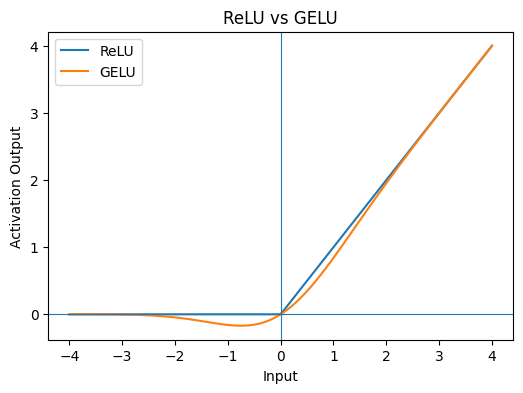

In [ ]:
# Code Cell: Plot ReLU vs GELU

import matplotlib.pyplot as plt

x_vals = torch.linspace(-4, 4, steps=200)
relu_curve = F.relu(x_vals)
gelu_curve = F.gelu(x_vals)

plt.figure(figsize=(6, 4))
plt.plot(x_vals.numpy(), relu_curve.numpy(), label="ReLU")
plt.plot(x_vals.numpy(), gelu_curve.numpy(), label="GELU")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("ReLU vs GELU")
plt.xlabel("Input")
plt.ylabel("Activation Output")
plt.legend()
plt.show()

### Observation

ReLU sharply clips negative values to zero.

GELU is smoother.

For classroom implementation, ReLU makes the expansion-nonlinearity-compression idea very clear.

For a BERT-style practical model, we will switch to GELU later.

## 5.9 FFN With GELU Activation

Let us create a second FFN module using GELU.

This is closer to BERT-style encoder implementations.

The structure remains the same:

```python
Linear(d_model, d_ff)
GELU()
Linear(d_ff, d_model)

In [ ]:
# Code Cell: Position-Wise Feed-Forward Network With GELU

class PositionWiseFeedForwardGELU(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# Code Cell: Test GELU-Based FFN

ffn_gelu = PositionWiseFeedForwardGELU(d_model=d_model, d_ff=d_ff)

ffn_gelu_out = ffn_gelu(X1)

print("Input shape:           ", X1.shape)
print("GELU FFN output shape: ", ffn_gelu_out.shape)

Input shape:            torch.Size([2, 5, 8])
GELU FFN output shape:  torch.Size([2, 5, 8])


### Observation

The activation function changes how values are transformed.

But the external shape remains unchanged.

This is the key requirement for integrating FFN inside the Transformer Encoder block.

## 5.10 FFN Parameter Count

Let us compute how many parameters the FFN contains.

For the first linear layer:

$$
d_{\text{model}} \times d_{\text{ff}} + d_{\text{ff}}
$$

For the second linear layer:

$$
d_{\text{ff}} \times d_{\text{model}} + d_{\text{model}}
$$

So the FFN often contains a large portion of Transformer parameters.

In [ ]:
# Code Cell: Count Parameters in FFN

def count_parameters(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

ffn_param_count = count_parameters(ffn)
ffn_gelu_param_count = count_parameters(ffn_gelu)

print("FFN with ReLU parameter count:", ffn_param_count)
print("FFN with GELU parameter count:", ffn_gelu_param_count)

FFN with ReLU parameter count: 552
FFN with GELU parameter count: 552


In [ ]:
# Code Cell: Manual Parameter Count Verification

manual_count = (d_model * d_ff + d_ff) + (d_ff * d_model + d_model)

print("Manual FFN parameter count:", manual_count)
print("PyTorch FFN parameter count:", ffn_param_count)

Manual FFN parameter count: 552
PyTorch FFN parameter count: 552


### Observation

Changing ReLU to GELU does not change the number of learnable parameters.

The learnable parameters come from the linear layers.

The activation function changes the transformation behavior, not the parameter count.

## 5.11 FFN Inside Encoder Block Skeleton

Now we update the encoder skeleton.

Earlier:

```python
attention_output = MHA(x)
x = AddNorm(x, attention_output)

Now:

attention_output = MHA(x)
x = AddNorm(x, attention_output)

ffn_output = FFN(x)

Next Step:

x = AddNorm(x, ffn_output)

In [ ]:
# Code Cell: Required Modules for Encoder Skeleton(Already Present in above code cells)

class LayerNormFromScratch(nn.Module):
    def __init__(self, d_model, eps=1e-5):
        super().__init__()

        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        variance = x.var(dim=-1, keepdim=True, unbiased=False)

        x_norm = (x - mean) / torch.sqrt(variance + self.eps)

        return self.gamma * x_norm + self.beta


class AddNorm(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.layer_norm = LayerNormFromScratch(d_model)

    def forward(self, x, sublayer_output):
        return self.layer_norm(x + sublayer_output)

In [ ]:
# Code Cell: Minimal MHA Module for Encoder Skeleton

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, d_model = x.shape

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q = Q.view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.d_head).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_head ** 0.5)
        attention_weights = F.softmax(scores, dim=-1)

        context = torch.matmul(attention_weights, V)
        context = context.transpose(1, 2).contiguous().view(B, T, d_model)

        out = self.W_o(context)

        return out, attention_weights

In [ ]:
# Code Cell: Encoder Skeleton With FFN Added

class EncoderBlockWithFFN(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()

        self.mha = MultiHeadSelfAttention(d_model, num_heads)
        self.add_norm1 = AddNorm(d_model)
        self.ffn = PositionWiseFeedForwardGELU(d_model, d_ff)

    def forward(self, x):
        attention_output, attention_weights = self.mha(x)
        x = self.add_norm1(x, attention_output)

        ffn_output = self.ffn(x)

        return x, ffn_output, attention_weights

In [ ]:
# Code Cell: Test Encoder Skeleton With FFN

encoder_with_ffn = EncoderBlockWithFFN(
    d_model=d_model,
    num_heads=2,
    d_ff=d_ff
)

x_after_first_add_norm, ffn_output, attention_weights = encoder_with_ffn(X1)

print("Input shape:                       ", X1.shape)
print("After first Add & Norm shape:      ", x_after_first_add_norm.shape)
print("FFN output shape:                  ", ffn_output.shape)
print("Attention weights shape:           ", attention_weights.shape)

Input shape:                        torch.Size([2, 5, 8])
After first Add & Norm shape:       torch.Size([2, 5, 8])
FFN output shape:                   torch.Size([2, 5, 8])
Attention weights shape:            torch.Size([2, 2, 5, 5])


### Observation

The FFN receives the output of the first Add & Norm.

It returns a tensor of the same shape:

$$
B \times T \times d_{\text{model}}
$$

This allows the second residual connection:

$$
X_1 + \text{FFN}(X_1)
$$

That is the next step.

## Concept Check Questions: Feed-Forward Network Inside Encoder Block

### Q1. Regular Question

What is the role of the Feed-Forward Network inside a Transformer Encoder block?

---

### Q2. Shape-Based Question

Suppose the input to the FFN has shape:

```python
x.shape = (16, 20, 256)
d_ff = 1024

What will be the shape after the first linear layer and after the second linear layer?



### Q3. MCQ

Which statement is correct about the position-wise FFN?

A. It mixes information across token positions.

B. It is applied independently to each token position.

C. It changes the sequence length.

D. It produces the attention matrix.

# Q4 Complete the code
```python
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        hidden = self.linear1(x)
        activated = ____________
        out = self.linear2(activated)
        return out

### Q5
Student defines the FFN as:
```python
self.linear1 = nn.Linear(d_model, d_ff)
self.linear2 = nn.Linear(d_ff, d_ff)
Will this create a problem for further operations? If yes, give reasons.

### Q6. Interview-Type Question

Why does the FFN first expand the representation to $d_{\text{ff}}$ and then project it back to $d_{\text{model}}$?

## Bridge to Next Topic

The FFN produces a transformed token representation:

$$
\text{FFN}(X_1)
$$

where:

$$
X_1 = \text{LayerNorm}(X + \text{MHA}(X))
$$

But as before, we do not directly pass this FFN output forward.

We apply another residual connection and LayerNorm:

$$
X_2 = \text{LayerNorm}(X_1 + \text{FFN}(X_1))
$$

This takes us to the next topic:

#### Second Residual + LayerNorm

## 6. Second Residual + LayerNorm

### Core Idea

After the Feed-Forward Network, the Transformer Encoder block applies another residual connection and LayerNorm.

The flow so far is:

$$
X_1 = \text{LayerNorm}(X + \text{MHA}(X))
$$

Then the FFN transforms this representation:

$$
\text{FFN}(X_1)
$$

But we do not directly pass the FFN output forward.

Instead, we apply:

$$
X_2 = \text{LayerNorm}(X_1 + \text{FFN}(X_1))
$$

This is the second Add & Norm operation inside the encoder block.

## 6.1 Why Do We Need the Second Residual Connection?

The FFN transforms each token representation independently.

But just like MHA, the FFN may also disturb useful information.

So the encoder block again uses a residual path:

$$
X_1 + \text{FFN}(X_1)
$$

This means:

- $X_1$ carries the current token representation,
- $\text{FFN}(X_1)$ carries a nonlinear token-wise update,
- their sum combines original and transformed information.

The model learns a refinement instead of replacing the representation completely.

## 6.2 Why LayerNorm Again?

After residual addition, the scale of token vectors may shift again.

So LayerNorm is applied again:

$$
X_2 = \text{LayerNorm}(X_1 + \text{FFN}(X_1))
$$

The second LayerNorm stabilizes the representation before the output is passed to:

- the next encoder block,
- or the final task-specific head.

So each encoder block ends with a stable output tensor.

In [ ]:
# Code Cell: Setup for Second Residual + LayerNorm(Repeated for live sessions)

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)

B = 2
T = 5
d_model = 8
d_ff = 32

X1 = torch.randn(B, T, d_model)

print("Input X1 shape:", X1.shape)

Input X1 shape: torch.Size([2, 5, 8])


## 6.3 Define LayerNorm and AddNorm Modules

We reuse the same LayerNorm and AddNorm modules.

The second Add & Norm has the same structure as the first Add & Norm.

Only the sub-layer changes.

First Add & Norm:

$$
\text{LayerNorm}(X + \text{MHA}(X))
$$

Second Add & Norm:

$$
\text{LayerNorm}(X_1 + \text{FFN}(X_1))
$$

In [ ]:
# Code Cell: LayerNorm From Scratch

class LayerNormFromScratch(nn.Module):
    def __init__(self, d_model, eps=1e-5):
        super().__init__()

        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        variance = x.var(dim=-1, keepdim=True, unbiased=False)

        x_norm = (x - mean) / torch.sqrt(variance + self.eps)

        return self.gamma * x_norm + self.beta


class AddNorm(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.layer_norm = LayerNormFromScratch(d_model)

    def forward(self, x, sublayer_output):
        return self.layer_norm(x + sublayer_output)

In [ ]:
# Code Cell: Position-Wise Feed-Forward Network With GELU

class PositionWiseFeedForwardGELU(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

## 6.4 Manual Second Add & Norm Step

The second Add & Norm can be implemented in three steps:

```python
ffn_output = FFN(X1)
residual_output_2 = X1 + ffn_output
X2 = LayerNorm(residual_output_2)

In [ ]:
# Code Cell: Manual Second Residual + LayerNorm

ffn = PositionWiseFeedForwardGELU(d_model=d_model, d_ff=d_ff)
ln2 = LayerNormFromScratch(d_model=d_model)

ffn_output = ffn(X1)

residual_output_2 = X1 + ffn_output

X2 = ln2(residual_output_2)

print("Input X1 shape:                 ", X1.shape)
print("FFN output shape:               ", ffn_output.shape)
print("Second residual output shape:   ", residual_output_2.shape)
print("Second Add & Norm output shape: ", X2.shape)

Input X1 shape:                  torch.Size([2, 5, 8])
FFN output shape:                torch.Size([2, 5, 8])
Second residual output shape:    torch.Size([2, 5, 8])
Second Add & Norm output shape:  torch.Size([2, 5, 8])


### Observation

Again, the shape remains:

$$
B \times T \times d_{\text{model}}
$$

The Transformer Encoder block preserves this shape from input to output.

The representation changes, but the tensor structure remains compatible with stacking.

## 6.5 Inspect One Token Through Second Add & Norm

Let us track one token through the second sub-layer.

We observe:

1. input to FFN,
2. FFN output,
3. residual addition,
4. LayerNorm output.

In [ ]:
# Code Cell: Track One Token Through Second Add & Norm

sentence_id = 0
token_id = 2

print("Input token X1:")
print(X1[sentence_id, token_id])

print("\nFFN output for token:")
print(ffn_output[sentence_id, token_id])

print("\nAfter second residual addition:")
print(residual_output_2[sentence_id, token_id])

print("\nAfter second Add & Norm:")
print(X2[sentence_id, token_id])

Input token X1:
tensor([ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806])

FFN output for token:
tensor([ 0.2171, -0.0646, -0.1167, -0.1099, -0.2330, -0.0090, -0.0845, -0.1708],
       grad_fn=<SelectBackward0>)

After second residual addition:
tensor([ 1.8594, -0.2242, -0.6141,  0.3297, -0.9911,  1.0693,  0.7163,  1.5098],
       grad_fn=<SelectBackward0>)

After second Add & Norm:
tensor([ 1.4741, -0.7158, -1.1256, -0.1337, -1.5219,  0.6437,  0.2726,  1.1067],
       grad_fn=<SelectBackward0>)


### Observation

The second Add & Norm again treats the sub-layer output as an update.

This gives:

```python
new_token = old_token + ffn_update

## 6.6 Statistics Before and After Second LayerNorm

As before, let us check the token-wise mean and variance.

Before LayerNorm, different token vectors may have different statistics.

After LayerNorm, each token vector should have mean close to 0 and variance close to 1.

In [ ]:
# Code Cell: Statistics Before and After Second LayerNorm

before_ln2_mean = residual_output_2.mean(dim=-1)
before_ln2_var = residual_output_2.var(dim=-1, unbiased=False)

after_ln2_mean = X2.mean(dim=-1)
after_ln2_var = X2.var(dim=-1, unbiased=False)

print("Mean before second LayerNorm:")
print(before_ln2_mean)

print("\nVariance before second LayerNorm:")
print(before_ln2_var)

print("\nMean after second LayerNorm:")
print(after_ln2_mean)

print("\nVariance after second LayerNorm:")
print(after_ln2_var)

Mean before second LayerNorm:
tensor([[-0.2416, -0.3565,  0.4569,  0.5641, -0.1723],
        [-0.3300, -0.1865,  0.2186,  0.5686, -0.3795]],
       grad_fn=<MeanBackward1>)

Variance before second LayerNorm:
tensor([[2.3589, 0.8633, 0.9052, 0.4386, 1.1015],
        [1.4775, 0.5754, 1.1770, 0.9523, 0.7211]], grad_fn=<VarBackward0>)

Mean after second LayerNorm:
tensor([[-2.9802e-08,  4.4703e-08, -2.9802e-08,  1.1176e-08,  0.0000e+00],
        [ 1.6298e-08, -5.2154e-08, -1.4901e-08, -6.7055e-08,  3.7253e-08]],
       grad_fn=<MeanBackward1>)

Variance after second LayerNorm:
tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]], grad_fn=<VarBackward0>)


### Observation

The second LayerNorm stabilizes the final output of the encoder block.

This is important because the next encoder block will receive this output as its input.

If normalization were absent, scale shifts could accumulate across stacked blocks.

## 6.7 Building a Reusable Second Add & Norm Module

The same `AddNorm` module can be reused after FFN.

The call is:

```python
x = add_norm2(x, ffn_output)

In [ ]:
# Code Cell: Test AddNorm as Second Add & Norm

add_norm2 = AddNorm(d_model=d_model)

X2_module = add_norm2(X1, ffn_output)

print("Manual-style X2 shape: ", X2.shape)
print("Module X2 shape:       ", X2_module.shape)

Manual-style X2 shape:  torch.Size([2, 5, 8])
Module X2 shape:        torch.Size([2, 5, 8])


### Observation

The AddNorm module can be reused because both sub-layers follow the same pattern:

```python
x = LayerNorm(x + sublayer_output)

## 6.8 Complete Encoder Block Pattern So Far

At this point, the encoder block logic is:

```python
attention_output = MHA(x)
x = AddNorm(x, attention_output)

ffn_output = FFN(x)
x = AddNorm(x, ffn_output)

In [ ]:
# Code Cell: Encoder Block With Second Add & Norm

class EncoderBlockWithSecondAddNorm(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()

        self.mha = MultiHeadSelfAttention(d_model, num_heads)
        self.add_norm1 = AddNorm(d_model)

        self.ffn = PositionWiseFeedForwardGELU(d_model, d_ff)
        self.add_norm2 = AddNorm(d_model)

    def forward(self, x):
        attention_output, attention_weights = self.mha(x)
        x = self.add_norm1(x, attention_output)

        ffn_output = self.ffn(x)
        x = self.add_norm2(x, ffn_output)

        return x, attention_weights

In [ ]:
# Code Cell: Multi-Head Self-Attention Module Required for Complete Test

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, d_model = x.shape

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q = Q.view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.d_head).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_head ** 0.5)
        attention_weights = F.softmax(scores, dim=-1)

        context = torch.matmul(attention_weights, V)

        context = context.transpose(1, 2).contiguous().view(B, T, d_model)

        out = self.W_o(context)

        return out, attention_weights

In [ ]:
# Code Cell: Test Encoder Block With Second Add & Norm

torch.manual_seed(42)

B = 2
T = 5
d_model = 8
num_heads = 2
d_ff = 32

X = torch.randn(B, T, d_model)

encoder_block_partial = EncoderBlockWithSecondAddNorm(
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff
)

encoder_output, attention_weights = encoder_block_partial(X)

print("Input shape:             ", X.shape)
print("Encoder output shape:    ", encoder_output.shape)
print("Attention weights shape: ", attention_weights.shape)

Input shape:              torch.Size([2, 5, 8])
Encoder output shape:     torch.Size([2, 5, 8])
Attention weights shape:  torch.Size([2, 2, 5, 5])


### Observation

Now we have implemented the full structural flow of one encoder block:

1. Multi-Head Attention
2. First Add & Norm
3. Feed-Forward Network
4. Second Add & Norm

The next step is to organize this cleanly as a complete Transformer Encoder Block forward pass.

## 6.9 Why There Are Two Add & Norm Operations

There are two major sub-layers inside the encoder block:

1. Multi-Head Self-Attention
2. Feed-Forward Network

Each sub-layer gets its own residual connection and LayerNorm.

So the encoder block has:

```python
MHA + AddNorm
FFN + AddNorm

## 6.10 Final View of One Encoder Block

The full encoder block can now be written as:

$$
X_1 = \text{LayerNorm}(X + \text{MHA}(X))
$$

$$
X_2 = \text{LayerNorm}(X_1 + \text{FFN}(X_1))
$$

where:

- $X$ is the input to the encoder block,
- $X_1$ is the output after attention sub-layer,
- $X_2$ is the final encoder block output.

This $X_2$ will either go to the next encoder block or to a task-specific model head.

## Concept Check Questions: Second Residual + LayerNorm

### Q1. Regular Question

Why does the Transformer Encoder block apply a second residual connection after the FFN?

---

### Q2. Formula-Based Question

Write the expression for the second Add & Norm operation after the Feed-Forward Network.

---

### Q3. Shape-Based Question

Suppose:

```python
X1.shape = (4, 12, 128)
ffn_output.shape = (4, 12, 128)
What will be the shape after the second Add & Norm?

### Q4. MCQ

Why is the FFN output projected back to $d_{\text{model}}$?

A. To reduce the batch size

B. To make it compatible with residual addition

C. To produce attention weights

D. To remove the need for LayerNorm

### Q5. A student writes:

```python
x = torch.randn(8, 10, 64)
ffn_output = torch.randn(8, 10, 128)

x = add_norm2(x, ffn_output)

Will it work?

### Q6. Interview-Type Question

Why does each major sub-layer inside the Transformer Encoder block have its own residual connection and LayerNorm?

### Answer

Each major sub-layer has its own residual connection and LayerNorm because each sub-layer changes the representation.

The residual connection preserves information and improves gradient flow.

LayerNorm stabilizes the output distribution after the residual addition.

Since MHA and FFN are separate transformations, both need their own Add & Norm step.

### Q7. Complete the missing line:
```python
ffn_output = ffn(x)

# Missing line
x = ______________________
Answer:
x = add_norm2(x, ffn_output)

## Bridge to Next Topic

We now have all components of the Transformer Encoder block:

1. Multi-Head Self-Attention
2. First Add & Norm
3. Feed-Forward Network
4. Second Add & Norm

The next step is to combine everything into a clean full forward pass:

#### Complete Transformer Encoder Block Forward Pass

## 7. Complete Transformer Encoder Block Forward Pass

### Core Idea

We have now built every component of one Transformer Encoder block.

The complete encoder block contains:

1. Multi-Head Self-Attention
2. First Add & Norm
3. Feed-Forward Network
4. Second Add & Norm

The full forward pass is:

$$
X_1 = \text{LayerNorm}(X + \text{MHA}(X))
$$

$$
X_2 = \text{LayerNorm}(X_1 + \text{FFN}(X_1))
$$

Here:

- $X$ is the input to the encoder block,
- $X_1$ is the output after attention + Add & Norm,
- $X_2$ is the final encoder block output.

The output shape remains:

$$
B \times T \times d_{\text{model}}
$$

## 7.1 Complete Encoder Block Flow

The encoder block forward pass can be written in code as:

```python
attention_output, attention_weights = self.mha(x)
x = self.add_norm1(x, attention_output)

ffn_output = self.ffn(x)
x = self.add_norm2(x, ffn_output)

return x, attention_weights

In [ ]:
# Code Cell: Setup

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)

B = 2
T = 6
d_model = 12
num_heads = 3
d_ff = 48

X = torch.randn(B, T, d_model)

print("Input X shape:", X.shape)

Input X shape: torch.Size([2, 6, 12])


## 7.2 Multi-Head Self-Attention Module

We first define Multi-Head Self-Attention.

This module:

1. projects input into $Q$, $K$, and $V$,
2. splits them into multiple heads,
3. computes scaled dot-product attention,
4. merges heads,
5. projects back to $d_{\text{model}}$.

The output shape must match the input shape.

In [ ]:
# Code Cell: Multi-Head Self-Attention

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        B, T, d_model = x.shape

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q = Q.view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.d_head).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_head ** 0.5)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attention_weights = F.softmax(scores, dim=-1)

        context = torch.matmul(attention_weights, V)

        context = context.transpose(1, 2).contiguous().view(B, T, d_model)

        out = self.W_o(context)

        return out, attention_weights

### Small Practical Note

This version includes an optional `mask`.

For now, we can run without a mask.

But in the upcoming mini NLP project, masking will become useful because real sentences may have different lengths and padding tokens should not receive attention.

## 7.3 LayerNorm From Scratch

Next, we define LayerNorm.

LayerNorm normalizes each token vector across the feature dimension.

It preserves the input shape.

In [ ]:
# Code Cell: LayerNorm From Scratch

class LayerNormFromScratch(nn.Module):
    def __init__(self, d_model, eps=1e-5):
        super().__init__()

        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        variance = x.var(dim=-1, keepdim=True, unbiased=False)

        x_norm = (x - mean) / torch.sqrt(variance + self.eps)

        return self.gamma * x_norm + self.beta

## 7.4 Add & Norm Module

Now we combine residual addition and LayerNorm into a reusable module.

The operation is:

$$
\text{AddNorm}(x, y) = \text{LayerNorm}(x + y)
$$

where:

- $x$ is the input to a sub-layer,
- $y$ is the output from that sub-layer.

This module will be used twice in the encoder block.

In [ ]:
# Code Cell: Add & Norm Module

class AddNorm(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.layer_norm = LayerNormFromScratch(d_model)

    def forward(self, x, sublayer_output):
        return self.layer_norm(x + sublayer_output)

## 7.5 Position-Wise Feed-Forward Network

The Feed-Forward Network transforms each token independently.

It follows the structure:

$$
d_{\text{model}} \rightarrow d_{\text{ff}} \rightarrow d_{\text{model}}
$$

We use GELU here because it connects well with BERT-style encoder models.

In [ ]:
# Code Cell: Position-Wise Feed-Forward Network

class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

## 7.6 Complete Transformer Encoder Block

Now we combine all components into one clean encoder block.

The forward pass is:

```python
attention_output, attention_weights = self.mha(x, mask)
x = self.add_norm1(x, attention_output)

ffn_output = self.ffn(x)
x = self.add_norm2(x, ffn_output)

return x, attention_weights

In [ ]:
# Code Cell: Complete Transformer Encoder Block

class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()

        self.mha = MultiHeadSelfAttention(d_model, num_heads)
        self.add_norm1 = AddNorm(d_model)
        self.ffn = PositionWiseFeedForward(d_model, d_ff)
        self.add_norm2 = AddNorm(d_model)

    def forward(self, x, mask=None):
        attention_output, attention_weights = self.mha(x, mask)
        x = self.add_norm1(x, attention_output)

        ffn_output = self.ffn(x)
        x = self.add_norm2(x, ffn_output)

        return x, attention_weights

## 7.7 Testing the Complete Encoder Block

Let us pass a random input tensor through the complete encoder block.

Input shape:

$$
B \times T \times d_{\text{model}}
$$

Expected output shape:

$$
B \times T \times d_{\text{model}}
$$

In [ ]:
# Code Cell: Test Complete Encoder Block

encoder_block = TransformerEncoderBlock(
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff
)

encoder_output, attention_weights = encoder_block(X)

print("Input shape:             ", X.shape)
print("Encoder output shape:    ", encoder_output.shape)
print("Attention weights shape: ", attention_weights.shape)

Input shape:              torch.Size([2, 6, 12])
Encoder output shape:     torch.Size([2, 6, 12])
Attention weights shape:  torch.Size([2, 3, 6, 6])


### Observation

The encoder block preserves the external tensor shape.

The input and output both have shape:

$$
B \times T \times d_{\text{model}}
$$

The attention weights have shape:

$$
B \times h \times T \times T
$$

where $h$ is the number of heads.

This attention tensor can be inspected to understand how tokens attend to each other.

## 7.8 Step-by-Step Forward Pass With Print Statements

For teaching, it is useful to see how the tensor moves inside the encoder block.

We now create a verbose version of the encoder block that prints shapes at each step.

In [ ]:
# Code Cell: Verbose Transformer Encoder Block

class VerboseTransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()

        self.mha = MultiHeadSelfAttention(d_model, num_heads)
        self.add_norm1 = AddNorm(d_model)
        self.ffn = PositionWiseFeedForward(d_model, d_ff)
        self.add_norm2 = AddNorm(d_model)

    def forward(self, x, mask=None):
        print("Input x shape:                  ", x.shape)

        attention_output, attention_weights = self.mha(x, mask)
        print("MHA output shape:               ", attention_output.shape)
        print("Attention weights shape:        ", attention_weights.shape)

        x = self.add_norm1(x, attention_output)
        print("After first Add & Norm shape:   ", x.shape)

        ffn_output = self.ffn(x)
        print("FFN output shape:               ", ffn_output.shape)

        x = self.add_norm2(x, ffn_output)
        print("After second Add & Norm shape:  ", x.shape)

        return x, attention_weights

In [ ]:
# Code Cell: Run Verbose Encoder Block

verbose_encoder_block = VerboseTransformerEncoderBlock(
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff
)

encoder_output_verbose, attention_weights_verbose = verbose_encoder_block(X)

Input x shape:                   torch.Size([2, 6, 12])
MHA output shape:                torch.Size([2, 6, 12])
Attention weights shape:         torch.Size([2, 3, 6, 6])
After first Add & Norm shape:    torch.Size([2, 6, 12])
FFN output shape:                torch.Size([2, 6, 12])
After second Add & Norm shape:   torch.Size([2, 6, 12])


### Observation

The internal operations change the representation but preserve the main shape.

This is why Transformer Encoder blocks can be stacked.

The output of one block can directly become the input of the next block.

## 7.9 Inspecting Attention From the Complete Block

The encoder block returns attention weights.

For one sentence and one head, the attention matrix has shape:

$$
T \times T
$$

Each row represents how one query token attends to all key tokens.

In [ ]:
# Code Cell: Inspect One Attention Matrix

sentence_id = 0
head_id = 0

attn_matrix = attention_weights[sentence_id, head_id]

print("Attention matrix shape:", attn_matrix.shape)
print(attn_matrix)

Attention matrix shape: torch.Size([6, 6])
tensor([[0.1083, 0.1883, 0.1571, 0.1475, 0.3095, 0.0894],
        [0.1327, 0.1695, 0.1551, 0.1983, 0.1968, 0.1477],
        [0.1318, 0.1841, 0.2004, 0.1468, 0.1521, 0.1848],
        [0.2806, 0.1276, 0.1307, 0.1327, 0.1103, 0.2181],
        [0.1820, 0.1547, 0.1534, 0.1804, 0.1518, 0.1776],
        [0.1122, 0.2076, 0.2368, 0.1067, 0.1641, 0.1725]],
       grad_fn=<SelectBackward0>)


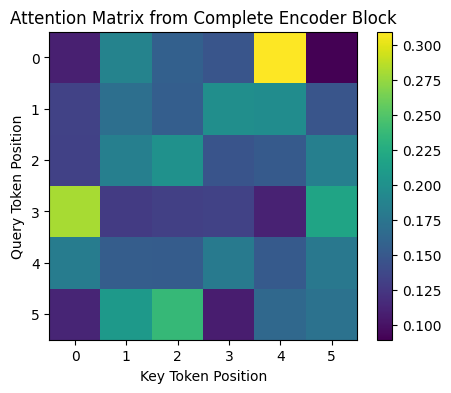

In [ ]:
# Code Cell: Visualize Attention Matrix

plt.figure(figsize=(5, 4))
plt.imshow(attn_matrix.detach().numpy())
plt.colorbar()
plt.title("Attention Matrix from Complete Encoder Block")
plt.xlabel("Key Token Position")
plt.ylabel("Query Token Position")
plt.show()

### Observation

Because the input is random, this attention map does not represent meaningful language behavior.

But technically, this is the same type of matrix that real Transformer models use to distribute attention across tokens.

Later, when we use real tokenized sentences, these matrices become more interpretable.

## 7.10 Checking Attention Row Sums

Since softmax is applied over the key-token dimension, each attention row should sum to 1.

Let us verify this.

In [ ]:
# Code Cell: Verify Attention Row Sums

row_sums = attn_matrix.sum(dim=-1)

print("Row sums of attention matrix:")
print(row_sums)

Row sums of attention matrix:
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)


### Observation

Each row sums approximately to 1.

This confirms that every query token distributes its attention probability over all key tokens.

## 7.11 Inspecting One Token Through the Complete Encoder Block

Now let us compare one token vector before and after the complete encoder block.

This shows that the shape remains the same, but the representation changes.

In [ ]:
# Code Cell: Compare One Token Before and After Encoder Block

sentence_id = 0
token_id = 2

print("Original token vector:")
print(X[sentence_id, token_id])

print("\nToken vector after complete encoder block:")
print(encoder_output[sentence_id, token_id])

Original token vector:
tensor([ 1.2791,  1.2964,  0.6105,  1.3347, -0.2316,  0.0418, -0.2516,  0.8599,
        -1.3847, -0.8712, -0.2234,  1.7174])

Token vector after complete encoder block:
tensor([ 1.0900,  0.9661,  0.7649,  0.8605, -0.7185, -0.7409, -0.2487,  0.5318,
        -2.2804, -0.9493, -0.2618,  0.9863], grad_fn=<SelectBackward0>)


### Observation

The token vector after the encoder block is different from the input token vector.

This change happened through:

1. contextual mixing using attention,
2. residual stabilization through first Add & Norm,
3. token-wise nonlinear transformation through FFN,
4. final stabilization through second Add & Norm.

So one encoder block performs one round of contextual refinement.

## 7.12 Comparing Input and Output Statistics

Since the block uses LayerNorm, the final token vectors should be stabilized.

Let us check token-wise mean and variance at the output.

In [ ]:
# Code Cell: Check Output Statistics

output_mean = encoder_output.mean(dim=-1)
output_var = encoder_output.var(dim=-1, unbiased=False)

print("Mean of output token vectors:")
print(output_mean)

print("\nVariance of output token vectors:")
print(output_var)

Mean of output token vectors:
tensor([[ 1.9868e-08, -7.4506e-09, -2.9802e-08,  1.9868e-08,  0.0000e+00,
          1.8626e-08],
        [ 4.4703e-08, -2.9802e-08, -7.4506e-09, -2.9802e-08, -2.9802e-08,
          9.9341e-09]], grad_fn=<MeanBackward1>)

Variance of output token vectors:
tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],
       grad_fn=<VarBackward0>)


### Observation

The output token vectors have mean close to 0 and variance close to 1.

This happens because the final operation inside the block is LayerNorm.

This stabilized output can be safely passed into the next encoder block.

## 7.13 Parameter Count of One Encoder Block

A Transformer Encoder block has learnable parameters in:

1. query projection,
2. key projection,
3. value projection,
4. output projection,
5. LayerNorm 1,
6. FFN,
7. LayerNorm 2.

Let us count the trainable parameters.

In [ ]:
# Code Cell: Count Parameters

def count_parameters(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

total_params = count_parameters(encoder_block)

print("Total trainable parameters in one encoder block:", total_params)

Total trainable parameters in one encoder block: 1884


In [ ]:
# Code Cell: Parameter Breakdown

for name, param in encoder_block.named_parameters():
    print(f"{name:35s} {tuple(param.shape)} -> {param.numel()} parameters")

mha.W_q.weight                      (12, 12) -> 144 parameters
mha.W_q.bias                        (12,) -> 12 parameters
mha.W_k.weight                      (12, 12) -> 144 parameters
mha.W_k.bias                        (12,) -> 12 parameters
mha.W_v.weight                      (12, 12) -> 144 parameters
mha.W_v.bias                        (12,) -> 12 parameters
mha.W_o.weight                      (12, 12) -> 144 parameters
mha.W_o.bias                        (12,) -> 12 parameters
add_norm1.layer_norm.gamma          (12,) -> 12 parameters
add_norm1.layer_norm.beta           (12,) -> 12 parameters
ffn.net.0.weight                    (48, 12) -> 576 parameters
ffn.net.0.bias                      (48,) -> 48 parameters
ffn.net.2.weight                    (12, 48) -> 576 parameters
ffn.net.2.bias                      (12,) -> 12 parameters
add_norm2.layer_norm.gamma          (12,) -> 12 parameters
add_norm2.layer_norm.beta           (12,) -> 12 parameters


### Observation

Most parameters come from linear layers.

In larger Transformer models, the FFN often contributes a large portion of the total parameters because:

$$
d_{\text{ff}}
$$

is usually much larger than:

$$
d_{\text{model}}
$$

## 7.14 Using PyTorch Built-In LayerNorm Version

Our custom LayerNorm is useful for learning.

But in practical models, we normally use:

```python
nn.LayerNorm(d_model)

In [ ]:
# Code Cell: Practical Transformer Encoder Block With nn.LayerNorm

class PracticalTransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()

        self.mha = MultiHeadSelfAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = PositionWiseFeedForward(d_model, d_ff)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        attention_output, attention_weights = self.mha(x, mask)
        x = self.norm1(x + attention_output)

        ffn_output = self.ffn(x)
        x = self.norm2(x + ffn_output)

        return x, attention_weights

In [ ]:
# Code Cell: Test Practical Encoder Block

practical_encoder_block = PracticalTransformerEncoderBlock(
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff
)

practical_output, practical_attention = practical_encoder_block(X)

print("Input shape:              ", X.shape)
print("Practical output shape:   ", practical_output.shape)
print("Practical attention shape:", practical_attention.shape)

Input shape:               torch.Size([2, 6, 12])
Practical output shape:    torch.Size([2, 6, 12])
Practical attention shape: torch.Size([2, 3, 6, 6])


### Observation

The practical version behaves structurally the same as our from-scratch version.

The main difference is that `nn.LayerNorm` is more reliable, optimized, and standard in real PyTorch implementations.

For teaching, the custom version builds understanding.

For projects, the built-in version is preferred.

## 7.15 Missing Pieces Before a Real NLP Model

At this stage, we have built the core encoder block.

But this block alone is not a complete NLP model.

A real text model still needs:

1. tokenization,
2. vocabulary,
3. token embeddings,
4. positional encoding,
5. padding,
6. attention mask,
7. pooling strategy,
8. classification head.

So far, we only used random input embeddings.

In the upcoming mini-project, we will connect this encoder block to actual text.

## 7.16 What We Have Actually Built

We have built the central computational unit of an encoder-style Transformer.

The block takes:

$$
X \in \mathbb{R}^{B \times T \times d_{\text{model}}}
$$

and returns:

$$
X_2 \in \mathbb{R}^{B \times T \times d_{\text{model}}}
$$

This means:

- input: one vector per token,
- output: one refined vector per token.

The output still contains token-level representations.

For sentence-level classification, we will need to convert token-level output into one sentence-level vector.

## Concept Check Questions: Complete Transformer Encoder Block Forward Pass

### Q1. Regular Question

List the four major operations inside one Transformer Encoder block.

---

### Q2. Formula-Based Question

Write the two main equations for the complete encoder block using Post-LN style.

---

### Q3. Shape-Based Question

Suppose the input to an encoder block is:

```python
X.shape = (32, 20, 768)
What should be the output shape of one encoder block?

### Q4. MCQ

Which component is responsible for mixing information across token positions?

A. LayerNorm

B. Feed-Forward Network

C. Multi-Head Self-Attention

D. Linear classification head

### Q5. MCQ

Which component transforms each token independently after attention has already mixed token information?

A. Feed-Forward Network

B. Attention mask

C. Positional encoding

D. Softmax over attention scores

### Q6. Practical Implementation Question

Complete the missing lines:
```python

def forward(self, x, mask=None):
    attention_output, attention_weights = self.mha(x, mask)
    x = ______________________

    ffn_output = self.ffn(x)
    x = ______________________

    return x, attention_weights

Assume:

self.add_norm1
self.add_norm2

are already defined.

### Q7. Debugging Question

A student creates a Transformer Encoder block where the FFN returns shape:
```python

(B, T, d_ff)

instead of:

(B, T, d_model)

Which part of the encoder block will break and why?

### Q8. Interpretation Question

If the encoder block output shape is still:

(B, T, d_model)

why do we say the representation has changed?

### Q9. Interview-Type Question

Why is a Transformer Encoder block not a complete NLP classifier by itself?

### Q10. Advanced Conceptual Question

Why is shape preservation important inside Transformer Encoder blocks?

### Answer 9

A Transformer Encoder block is not a complete NLP classifier because it only processes token embeddings.

It does not include:

tokenization,
vocabulary mapping,
token embeddings,
positional encoding,
pooling,
classification head,
training objective.

For classification, we need to convert the encoder output into sentence-level logits.

### Answer 10

Shape preservation is important because it allows encoder blocks to be stacked.

If one block outputs:

(B, T, d_model)

then the next block can accept the same tensor shape as input.

This repeated shape compatibility makes deep Transformer Encoder models possible.

## Bridge to Next Topic

We have now completed the full Transformer Encoder block.

But this block still receives random input vectors in our examples.

To use it for NLP, we need to connect it with actual text.

That requires:

- tokenization,
- vocabulary,
- embeddings,
- positional encoding,
- padding,
- attention masks,
- pooling,
- classification head.

So before jumping to Hugging Face pipelines, we will build a small NLP project using our own Transformer Encoder.

Next topic:

#### Mini NLP Project Using Our Transformer Encoder

## 8. Mini NLP Project Using Our Transformer Encoder

### Core Idea

So far, we have built a complete Transformer Encoder block.

But till now, we were passing random tensors like:

```python
X = torch.randn(B, T, d_model)

Now we will connect the encoder block to real NLP data.

We will build a small sentiment classifier using:

manual text dataset,

simple tokenization,

vocabulary creation,

padding,

token embeddings,

positional embeddings,

one Transformer Encoder block,

pooling,

classification head.

In this first version, we will use only one encoder block.

## 8.1 Project Goal

We want to classify short text sentences as:

```text
Positive sentiment → 1
Negative sentiment → 0

Example:

"this movie was amazing" → Positive

"this movie was boring" → Negative

### The model flow will be:

Text
→ Token IDs
→ Token Embeddings
→ Positional Embeddings
→ Transformer Encoder Block
→ Sentence Pooling
→ Classification Head
→ Sentiment Prediction

This is a simplified version of how encoder-style models are used for text classification.

In [ ]:
# Code Cell: Imports

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)

## 8.2 Create a Small Sentiment Dataset

We create a tiny dataset manually.

This is not meant to build a high-accuracy production model.

The goal is to understand the full pipeline:

```text
Raw text → Transformer Encoder → Classification

In [ ]:
# Code Cell: Small Sentiment Dataset

texts = [
    "this movie was amazing",
    "i loved this film",
    "the acting was fantastic",
    "what a wonderful story",
    "this film was great",
    "i really enjoyed the movie",
    "the performance was excellent",
    "this was a beautiful experience",

    "this movie was terrible",
    "i hated this film",
    "the acting was boring",
    "what a bad story",
    "this film was awful",
    "i really disliked the movie",
    "the performance was poor",
    "this was a disappointing experience"
]

labels = [
    1, 1, 1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0
]

print("Number of samples:", len(texts))

Number of samples: 16


## 8.3 Simple Tokenization

For this mini-project, we use basic whitespace tokenization.

Example:

```text
"this movie was amazing"
becomes:

["this", "movie", "was", "amazing"]

This is not how production tokenizers work, but it is enough for understanding the model pipeline.

In [ ]:
# Code Cell: Tokenize Text

def tokenize(text):
    return text.lower().split()

tokenized_texts = [tokenize(text) for text in texts]

for text, tokens in zip(texts[:3], tokenized_texts[:3]):
    print(text, "->", tokens)

this movie was amazing -> ['this', 'movie', 'was', 'amazing']
i loved this film -> ['i', 'loved', 'this', 'film']
the acting was fantastic -> ['the', 'acting', 'was', 'fantastic']


## 8.4 Build Vocabulary

A neural network cannot directly process words.

So we map each word to an integer ID.

We also add two special tokens:

```text
<PAD> → used for padding shorter sentences
<UNK> → used for unknown words

In [ ]:
# Code Cell: Build Vocabulary

special_tokens = ["<PAD>", "<UNK>"]

vocab = {}

for token in special_tokens:
    vocab[token] = len(vocab)

for tokens in tokenized_texts:
    for token in tokens:
        if token not in vocab:
            vocab[token] = len(vocab)

id_to_word = {idx: word for word, idx in vocab.items()}

print("Vocabulary size:", len(vocab))
print(vocab)

Vocabulary size: 31
{'<PAD>': 0, '<UNK>': 1, 'this': 2, 'movie': 3, 'was': 4, 'amazing': 5, 'i': 6, 'loved': 7, 'film': 8, 'the': 9, 'acting': 10, 'fantastic': 11, 'what': 12, 'a': 13, 'wonderful': 14, 'story': 15, 'great': 16, 'really': 17, 'enjoyed': 18, 'performance': 19, 'excellent': 20, 'beautiful': 21, 'experience': 22, 'terrible': 23, 'hated': 24, 'boring': 25, 'bad': 26, 'awful': 27, 'disliked': 28, 'poor': 29, 'disappointing': 30}


## 8.5 Convert Text to Token IDs

Now every sentence becomes a sequence of integers.

For example:

```text
"this movie was amazing"
may become:

[2, 3, 4, 5]

In [ ]:
# Code Cell: Numerical Encoding

def numericalize(tokens, vocab):
    return [vocab.get(token, vocab["<UNK>"]) for token in tokens]

encoded_texts = [numericalize(tokens, vocab) for tokens in tokenized_texts]

for text, encoded in zip(texts[:5], encoded_texts[:5]):
    print(text)
    print(encoded)
    print()

this movie was amazing
[2, 3, 4, 5]

i loved this film
[6, 7, 2, 8]

the acting was fantastic
[9, 10, 4, 11]

what a wonderful story
[12, 13, 14, 15]

this film was great
[2, 8, 4, 16]



## 8.6 Padding Sentences

Neural networks process batches.

For batching, all sequences in a batch should have the same length.

So we pad shorter sentences with:

```text
<PAD>

In [ ]:
# Code Cell: Padding Function
max_len = 6
pad_id = vocab["<PAD>"]

def pad_sequence(seq, max_len, pad_id):
    if len(seq) > max_len:
        return seq[:max_len]
    return seq + [pad_id] * (max_len - len(seq))

padded_texts = [pad_sequence(seq, max_len, pad_id) for seq in encoded_texts]

for text, padded in zip(texts[:5], padded_texts[:5]):
    print(text)
    print(padded)
    print()

this movie was amazing
[2, 3, 4, 5, 0, 0]

i loved this film
[6, 7, 2, 8, 0, 0]

the acting was fantastic
[9, 10, 4, 11, 0, 0]

what a wonderful story
[12, 13, 14, 15, 0, 0]

this film was great
[2, 8, 4, 16, 0, 0]



## 8.7 Create Attention Mask

Padding tokens are not real words.

So the model should not give attention to padding positions.

We create an attention mask:

```text
1 → real token
0 → padding token

Example:

[2, 3, 4, 5, 0, 0]

becomes:

[1, 1, 1, 1, 0, 0]

In [ ]:
# Code Cell: Create Attention Masks

attention_masks = []

for seq in padded_texts:
    mask = [1 if token_id != pad_id else 0 for token_id in seq]
    attention_masks.append(mask)

for padded, mask in zip(padded_texts[:5], attention_masks[:5]):
    print("Token IDs:", padded)
    print("Mask:     ", mask)
    print()

Token IDs: [2, 3, 4, 5, 0, 0]
Mask:      [1, 1, 1, 1, 0, 0]

Token IDs: [6, 7, 2, 8, 0, 0]
Mask:      [1, 1, 1, 1, 0, 0]

Token IDs: [9, 10, 4, 11, 0, 0]
Mask:      [1, 1, 1, 1, 0, 0]

Token IDs: [12, 13, 14, 15, 0, 0]
Mask:      [1, 1, 1, 1, 0, 0]

Token IDs: [2, 8, 4, 16, 0, 0]
Mask:      [1, 1, 1, 1, 0, 0]



## 8.8 Create PyTorch Dataset

Now we prepare a custom PyTorch dataset.

Each sample will return:

```python
input_ids
attention_mask
label

In [ ]:
# Code Cell: Dataset Class

class SentimentDataset(Dataset):
    def __init__(self, input_ids, attention_masks, labels):
        self.input_ids = torch.tensor(input_ids, dtype=torch.long)
        self.attention_masks = torch.tensor(attention_masks, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_masks[idx],
            "label": self.labels[idx]
        }

dataset = SentimentDataset(padded_texts, attention_masks, labels)

sample = dataset[0]

print(sample)

{'input_ids': tensor([2, 3, 4, 5, 0, 0]), 'attention_mask': tensor([1, 1, 1, 1, 0, 0]), 'label': tensor(1)}


In [ ]:
# Code Cell: DataLoader

batch_size = 4

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

batch = next(iter(dataloader))

print("input_ids shape:     ", batch["input_ids"].shape)
print("attention_mask shape:", batch["attention_mask"].shape)
print("label shape:         ", batch["label"].shape)

input_ids shape:      torch.Size([4, 6])
attention_mask shape: torch.Size([4, 6])
label shape:          torch.Size([4])


## 8.9 Reuse the Transformer Encoder Block

Now we define the same Transformer Encoder components:

1. Multi-Head Self-Attention
2. Add & Norm
3. Feed-Forward Network
4. Complete Encoder Block

This time, we include attention masking properly.

The mask shape must be broadcastable to attention scores.

Attention scores have shape:

$$
B \times h \times T \times T
$$

So the mask should become:

$$
B \times 1 \times 1 \times T
$$

This tells every query token which key positions are real and which are padding.

In [ ]:
# Code Cell: Multi-Head Self-Attention With Padding Mask

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x, attention_mask=None):
        B, T, d_model = x.shape

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q = Q.view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.d_head).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_head ** 0.5)

        if attention_mask is not None:
            # attention_mask shape: (B, T)
            # converted to: (B, 1, 1, T)
            mask = attention_mask[:, None, None, :]
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attention_weights = F.softmax(scores, dim=-1)

        context = torch.matmul(attention_weights, V)
        context = context.transpose(1, 2).contiguous().view(B, T, d_model)

        out = self.W_o(context)

        return out, attention_weights

In [ ]:
# Code Cell: AddNorm and FFN

class AddNorm(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, sublayer_output):
        return self.norm(x + sublayer_output)


class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# Code Cell: Complete Transformer Encoder Block

class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()

        self.mha = MultiHeadSelfAttention(d_model, num_heads)
        self.add_norm1 = AddNorm(d_model)
        self.ffn = PositionWiseFeedForward(d_model, d_ff)
        self.add_norm2 = AddNorm(d_model)

    def forward(self, x, attention_mask=None):
        attention_output, attention_weights = self.mha(x, attention_mask)
        x = self.add_norm1(x, attention_output)

        ffn_output = self.ffn(x)
        x = self.add_norm2(x, ffn_output)

        return x, attention_weights

## 8.10 Add Token Embedding and Positional Embedding

The encoder block expects input of shape:

$$
B \times T \times d_{\text{model}}
$$

But our input is token IDs of shape:

$$
B \times T
$$

So first we need an embedding layer:

```python
nn.Embedding(vocab_size, d_model)

In [ ]:
# Code Cell: Single-Block Transformer Sentiment Classifier

class SingleBlockTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, max_len, num_classes):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.position_embedding = nn.Embedding(max_len, d_model)

        self.encoder = TransformerEncoderBlock(d_model, num_heads, d_ff)

        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, input_ids, attention_mask=None):
        B, T = input_ids.shape

        positions = torch.arange(T, device=input_ids.device).unsqueeze(0).expand(B, T)

        token_emb = self.token_embedding(input_ids)
        pos_emb = self.position_embedding(positions)

        x = token_emb + pos_emb

        encoder_output, attention_weights = self.encoder(x, attention_mask)

        # Mean pooling over non-padding tokens
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1)
            masked_output = encoder_output * mask
            pooled = masked_output.sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        else:
            pooled = encoder_output.mean(dim=1)

        logits = self.classifier(pooled)

        return logits, attention_weights

## 8.11 Test Forward Pass

Before training, always test whether the model produces the expected output shape.

For binary classification:

$$
\text{logits shape} = B \times 2
$$

In [ ]:
# Code Cell: Test Single-Block Model Forward Pass

vocab_size = len(vocab)
d_model = 32
num_heads = 4
d_ff = 64
num_classes = 2

single_model = SingleBlockTransformerClassifier(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff,
    max_len=max_len,
    num_classes=num_classes
)

batch = next(iter(dataloader))

logits, attention_weights = single_model(
    batch["input_ids"],
    batch["attention_mask"]
)

print("Input IDs shape:       ", batch["input_ids"].shape)
print("Logits shape:          ", logits.shape)
print("Attention weights shape:", attention_weights.shape)

Input IDs shape:        torch.Size([4, 6])
Logits shape:           torch.Size([4, 2])
Attention weights shape: torch.Size([4, 4, 6, 6])


### Observation

The model takes token IDs of shape:

$$
B \times T
$$

and produces logits of shape:

$$
B \times 2
$$

This means the model is now a complete text classifier.

The Transformer Encoder output has been pooled into one sentence-level vector.

## 8.12 Training the Single-Block Transformer Classifier

Now we train the model.

Because the dataset is very small, the model may quickly overfit.

That is acceptable here because our goal is not production accuracy.

Our goal is to understand the full Transformer-based classification pipeline.

In [ ]:
# Code Cell: Training Setup

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(single_model.parameters(), lr=0.005)

num_epochs = 40

In [ ]:
# Code Cell: Training Loop

single_model.train()

for epoch in range(num_epochs):
    total_loss = 0

    for batch in dataloader:
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels_batch = batch["label"]

        logits, _ = single_model(input_ids, attention_mask)

        loss = criterion(logits, labels_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1:02d} | Loss: {avg_loss:.4f}")

Epoch 05 | Loss: 0.5575
Epoch 10 | Loss: 0.0148
Epoch 15 | Loss: 0.0009
Epoch 20 | Loss: 0.0005
Epoch 25 | Loss: 0.0005
Epoch 30 | Loss: 0.0004
Epoch 35 | Loss: 0.0004
Epoch 40 | Loss: 0.0003


## 8.13 Evaluate on Training Examples

Now we check whether the model learned the tiny dataset.

Again, this is not a real benchmark.

It is a sanity check that our pipeline works.

In [ ]:
# Code Cell: Prediction Function

def predict_sentiment(model, text, vocab, max_len):
    model.eval()

    tokens = tokenize(text)
    ids = numericalize(tokens, vocab)
    padded = pad_sequence(ids, max_len, vocab["<PAD>"])
    mask = [1 if token_id != vocab["<PAD>"] else 0 for token_id in padded]

    input_ids = torch.tensor([padded], dtype=torch.long)
    attention_mask = torch.tensor([mask], dtype=torch.long)

    with torch.no_grad():
        logits, attention_weights = model(input_ids, attention_mask)
        probs = F.softmax(logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()

    label = "Positive" if pred == 1 else "Negative"

    return label, probs.squeeze(), attention_weights

In [ ]:
# Code Cell: Test Predictions on Known Sentences

test_sentences = [
    "this movie was amazing",
    "this movie was terrible",
    "the acting was fantastic",
    "the acting was boring"
]

for sentence in test_sentences:
    label, probs, _ = predict_sentiment(single_model, sentence, vocab, max_len)
    print(f"Text: {sentence}")
    print(f"Prediction: {label}")
    print(f"Probabilities: {probs}")
    print()

Text: this movie was amazing
Prediction: Positive
Probabilities: tensor([2.7350e-04, 9.9973e-01])

Text: this movie was terrible
Prediction: Negative
Probabilities: tensor([9.9966e-01, 3.4272e-04])

Text: the acting was fantastic
Prediction: Positive
Probabilities: tensor([3.1664e-04, 9.9968e-01])

Text: the acting was boring
Prediction: Negative
Probabilities: tensor([9.9964e-01, 3.6431e-04])



## 8.14 Test on Slightly New Sentences

Now we try sentences that are similar but not exactly the same as the training data.

This helps us see whether the model has learned some reusable pattern or only memorized.

In [ ]:
# Code Cell: Test on New Sentences

new_sentences = [
    "what a fantastic movie",
    "this story was awful",
    "i enjoyed this film",
    "i disliked the performance"
]

for sentence in new_sentences:
    label, probs, _ = predict_sentiment(single_model, sentence, vocab, max_len)
    print(f"Text: {sentence}")
    print(f"Prediction: {label}")
    print(f"Probabilities: {probs}")
    print()

Text: what a fantastic movie
Prediction: Positive
Probabilities: tensor([3.1684e-04, 9.9968e-01])

Text: this story was awful
Prediction: Negative
Probabilities: tensor([9.9954e-01, 4.5522e-04])

Text: i enjoyed this film
Prediction: Positive
Probabilities: tensor([3.5368e-04, 9.9965e-01])

Text: i disliked the performance
Prediction: Negative
Probabilities: tensor([0.7842, 0.2158])



### Observation

The model may perform well on sentences that use familiar words and familiar patterns.

But it may struggle with sentences that contain unseen words or different phrasing.

This is expected.

We trained a small Transformer from scratch on a tiny dataset.

It has architecture, but it does not have broad language knowledge.

## 8.15 Visualize Attention for One Sentence

Let us inspect attention weights for one example.

The attention matrix tells us how each token attends to other tokens.

Since this model is trained on a tiny dataset, the attention pattern should not be over-interpreted.

But it is useful to see that the mechanism is working.

In [ ]:
# Code Cell: Get Attention Weights for One Sentence

example_sentence = "this movie was amazing"

label, probs, attention_weights = predict_sentiment(
    single_model,
    example_sentence,
    vocab,
    max_len
)

tokens = tokenize(example_sentence)
ids = numericalize(tokens, vocab)
padded = pad_sequence(ids, max_len, vocab["<PAD>"])
tokens_padded = tokens + ["<PAD>"] * (max_len - len(tokens))

print("Sentence:", example_sentence)
print("Prediction:", label)
print("Tokens:", tokens_padded)
print("Attention shape:", attention_weights.shape)

Sentence: this movie was amazing
Prediction: Positive
Tokens: ['this', 'movie', 'was', 'amazing', '<PAD>', '<PAD>']
Attention shape: torch.Size([1, 4, 6, 6])


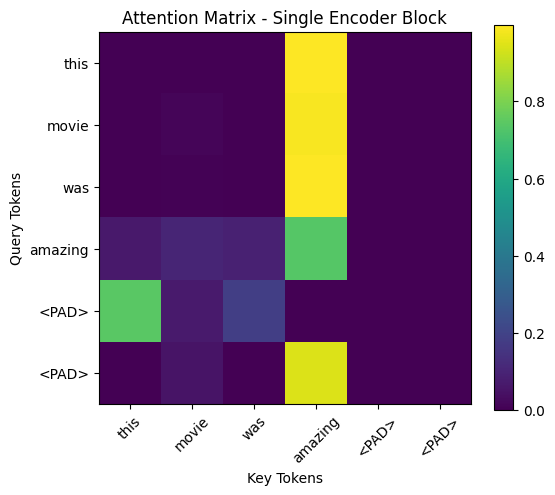

In [ ]:
# Code Cell: Visualize Attention Matrix for One Head

import matplotlib.pyplot as plt

head_id = 0
attn_matrix = attention_weights[0, head_id].detach()

plt.figure(figsize=(6, 5))
plt.imshow(attn_matrix)
plt.colorbar()
plt.xticks(range(max_len), tokens_padded, rotation=45)
plt.yticks(range(max_len), tokens_padded)
plt.title("Attention Matrix - Single Encoder Block")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.show()

### Observation

This attention map comes from a single encoder block.

It shows one level of token interaction.

At this point, the model has only one chance to mix token information and refine token representations.

Now comes the natural question:

> Is one encoder block enough for learning richer language representations?

This question will lead us to stacking.

## 8.16 Realisation Point: What Is Missing?

Our single-block model works as a complete Transformer-based classifier.

But it is still limited.

It has only one cycle of:

```text
attention mixing → token transformation

That means:

only one level of contextual refinement,

only one attention operation,

only one FFN transformation,

limited abstraction depth.

For simple toy sentences, this may be enough.

For real language, it is usually not enough.

Language understanding often needs multiple levels:

word meaning → phrase meaning → sentence meaning → task-specific meaning

This is why encoder blocks are stacked.

## Concept Check Questions: Single-Block Transformer Mini Project

### Q1. Regular Question

Why do we need an embedding layer before passing text into the Transformer Encoder block?

---

### Q2. Regular Question

Why do we add positional embeddings to token embeddings?

---

### Q3. Shape-Based Question

If `input_ids` has shape:

```python
(B, T)

and the embedding dimension is d_model, what is the shape after token embedding?

### Q4. MCQ

What does the attention mask indicate?

A. Which tokens are positive

B. Which positions are real tokens and which are padding

C. Which words are nouns

D. Which class the sentence belongs to

### Q5. Practical Question

Why do we apply pooling after the Transformer Encoder output?

### Answer:
The Transformer Encoder output has one vector per token:

(B, T, d_model)

But sentence classification needs one vector per sentence:

(B, d_model)

Pooling converts token-level representations into a sentence-level representation.

### Q6. Interview-Type Question

Why can a model trained from scratch on a tiny dataset fail on new sentences even if it uses a Transformer architecture?

### Q7. Conceptual Question

Why can a single encoder block be limited for real NLP tasks?

## Bridge to Next Topic

We now have a working sentiment classifier using one Transformer Encoder block.

This model helps students see that the architecture is functional.

But it also exposes an important limitation:

```text
One encoder block gives only one level of representation refinement.

## Teaching Note

This order is excellent for class delivery. Students first see that a single block can actually classify text. Then, when the model feels limited, stacking becomes an organic solution. The limitation is not just theoretical anymore; they have seen that one block gives only one refinement cycle. The next section should introduce a `TransformerEncoderStack` with `num_layers=2` or `num_layers=3`, then compare parameter count, representation changes, and predictions.